<a href="https://colab.research.google.com/github/santimsoler/APLICACIONFINAL_PROGRAMACION_UBA/blob/main/CASEN_2024_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CASEN 2024 — Perfiles de vulnerabilidad dentro de la pobreza multidimensional
## Taller de Programación — UBA | Versión final

### Pregunta de investigación

**¿Existen perfiles diferenciados de vulnerabilidad dentro de los hogares pobres multidimensionales de Chile y qué variables permiten caracterizar y reproducir esos perfiles?**

### Herramientas principales

Este trabajo utiliza únicamente **dos herramientas principales vistas en clase**:

1. **Análisis de Componentes Principales (PCA)**  
   Se utiliza para explorar y representar la estructura multidimensional de las condiciones de bienestar.

2. **K-Means**  
   Se utiliza para identificar perfiles de vulnerabilidad dentro de los hogares pobres multidimensionales.

Como extensión metodológica inspirada en **Caruso, Sosa-Escudero y Svarc (2011)**, se aplica posteriormente una **aproximación al procedimiento de blinding de Fraiman et al.** para evaluar qué subconjunto de variables originales reproduce la partición obtenida.

### Principio metodológico

La pobreza multidimensional oficial se utiliza para **definir el universo de análisis**, no como variable a predecir.

El análisis se concentra en:

\[
\text{CASEN 2024}
\rightarrow
\text{hogares pobres multidimensionales}
\rightarrow
\text{PCA}
\rightarrow
\text{K-Means}
\rightarrow
\text{perfiles}
\rightarrow
\text{Fraiman/blinding}
\]

### Importante

- Se utilizan variables crudas o construcciones directas a partir de preguntas de CASEN.
- No se utilizan las carencias oficiales como variables de clustering.
- Las tasas descriptivas utilizan el factor de expansión `expr`.
- K-Means incorpora `expr` como peso muestral.
- PCA se utiliza como herramienta exploratoria de representación geométrica.
- Fraiman se interpreta como procedimiento complementario de reducción/selección de variables, no como una tercera herramienta principal.

In [17]:
# ============================================================
# 0. INSTALACIÓN
# ============================================================

%pip -q install pyreadstat pyarrow matplotlib-venn

In [18]:
# ============================================================
# 1. LIBRERÍAS Y PARÁMETROS
# ============================================================

import os
import re
import glob
import json
import warnings
import textwrap
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pyreadstat

from google.colab import drive

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score
)

from matplotlib_venn import venn2


# ============================================================
# CONFIGURACIÓN GENERAL
# ============================================================

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


# ============================================================
# RUTAS
# ============================================================

CASEN_PATH = None
GEO_PATH = None

RESULTS_DIR = (
    "/content/drive/MyDrive/FINAL/"
    "CASEN2024_FINAL_PCA_KMEANS"
)

FIG_DIR = os.path.join(
    RESULTS_DIR,
    "figuras"
)


# ============================================================
# K-MEANS
# ============================================================

K_MIN = 2
K_MAX = 7
K_FINAL = 2


# ============================================================
# PCA
# ============================================================

PCA_N_COMPONENTS = 6
PCA_SCATTER_SAMPLE = 5000


# ============================================================
# FRAIMAN / BLINDING
# ============================================================

RUN_FRAIMAN = True
FRAIMAN_SAMPLE_N = 1400
FRAIMAN_TARGET_AGREEMENT = 0.90
FRAIMAN_NEIGHBORS = 15


print("Configuración cargada correctamente.")
print("La creación de carpetas se realizará después de montar Drive.")

Configuración cargada correctamente.
La creación de carpetas se realizará después de montar Drive.


In [19]:
# ============================================================
# 2. MONTAR GOOGLE DRIVE
# ============================================================

from google.colab import drive
from pathlib import Path
import os

drive.mount(
    "/content/drive"
)

print("Google Drive montado correctamente.")


# ============================================================
# CREAR CARPETAS SOLO DESPUÉS DEL MONTAJE
# ============================================================

Path(
    RESULTS_DIR
).mkdir(
    parents=True,
    exist_ok=True
)

Path(
    FIG_DIR
).mkdir(
    parents=True,
    exist_ok=True
)

print("Carpeta de resultados:")
print(RESULTS_DIR)

print("\nCarpeta de figuras:")
print(FIG_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive montado correctamente.
Carpeta de resultados:
/content/drive/MyDrive/FINAL/CASEN2024_FINAL_PCA_KMEANS

Carpeta de figuras:
/content/drive/MyDrive/FINAL/CASEN2024_FINAL_PCA_KMEANS/figuras


In [20]:
# ============================================================
# 3. LOCALIZAR AUTOMÁTICAMENTE LAS BASES
# ============================================================

def buscar_archivos(root, patrones):
    encontrados = []

    for patron in patrones:
        encontrados.extend(
            glob.glob(
                os.path.join(root, "**", patron),
                recursive=True
            )
        )

    return sorted(
        set(encontrados),
        key=lambda x: os.path.getsize(x),
        reverse=True
    )


if CASEN_PATH is None:
    candidatos = buscar_archivos(
        "/content/drive/MyDrive",
        [
            "casen_2024.dta",
            "Casen_2024.dta",
            "CASEN_2024.dta",
            "*casen*2024*.dta",
        ]
    )

    # Excluir archivos de provincia/comuna de la búsqueda principal
    candidatos_principal = [
        p for p in candidatos
        if "provincia" not in p.lower()
        and "comuna" not in p.lower()
    ]

    if candidatos_principal:
        CASEN_PATH = candidatos_principal[0]


if GEO_PATH is None:
    geo_candidates = buscar_archivos(
        "/content/drive/MyDrive",
        [
            "*casen*2024*provincia*comuna*.dta",
            "*provincia*comuna*.dta",
        ]
    )

    if geo_candidates:
        GEO_PATH = geo_candidates[0]


if CASEN_PATH is None:
    raise FileNotFoundError(
        "No encontré automáticamente casen_2024.dta. "
        "Escribe su ruta en CASEN_PATH."
    )


print("Base principal:")
print(CASEN_PATH)

print("\nBase geográfica:")
print(GEO_PATH if GEO_PATH else "No encontrada; no es obligatoria.")

Base principal:
/content/drive/MyDrive/Final/casen_2024.dta

Base geográfica:
No encontrada; no es obligatoria.


# PARTE I — Carga y construcción de la base a nivel hogar

La unidad de análisis final es el **hogar**. Se agregan variables de Educación, Salud, Vivienda y Redes/Cohesión Social utilizando información de todos los integrantes cuando corresponde.

In [21]:
# ============================================================
# 4. LEER METADATOS SIN CARGAR LAS 877 COLUMNAS
# ============================================================

_, meta = pyreadstat.read_dta(
    CASEN_PATH,
    metadataonly=True
)

ALL_COLUMNS = list(meta.column_names)

VAR_LABELS = {
    col: (lab if lab is not None else "")
    for col, lab in zip(
        meta.column_names,
        meta.column_labels
    )
}

VALUE_LABELS = (
    getattr(meta, "variable_value_labels", {})
    or {}
)

print(
    "Número total de variables en CASEN:",
    len(ALL_COLUMNS)
)


def buscar_variable(texto, top=20):
    texto = texto.lower()

    resultados = []

    for c in ALL_COLUMNS:
        lab = VAR_LABELS.get(c, "")
        if texto in f"{c} {lab}".lower():
            resultados.append(
                (c, lab)
            )

    return pd.DataFrame(
        resultados[:top],
        columns=["variable", "etiqueta"]
    )


display(
    buscar_variable("pobreza", 30)
)

Número total de variables en CASEN: 877


,variable,etiqueta
0,ymonecorh,Ingreso total corregido del hogar sin alquiler...
1,no_arrienda,Situación de arrendamiento para asignación de ...
2,lp,Línea de pobreza
3,pobreza,Situación de pobreza por ingresos
4,lp_2013,Línea de pobreza (metodología 2013)
5,pobreza_2013,Situación de pobreza por ingresos (metodología...
6,pobreza_severa,Pobreza severa
7,pobreza_multi,Indicador de pobreza multidimensional
8,pobreza_multi_2015,Indicador de pobreza multidimensional (metodol...


## Nombres descriptivos de las variables

El código interno de CASEN se necesita para programar, pero **no se utilizará como etiqueta en tablas ni gráficos**.

La función siguiente toma automáticamente la etiqueta oficial almacenada en el archivo `.dta`. Para variables construidas a nivel hogar utiliza nombres académicos más breves y legibles. El código CASEN queda únicamente en un diccionario técnico de trazabilidad.


In [22]:
# ============================================================
# 4B. NOMBRES DESCRIPTIVOS PARA TABLAS Y GRÁFICOS
# ============================================================

import textwrap

DERIVED_LABELS = {
    # Background
    "n_personas": "Número de integrantes del hogar",
    "edad_jefe": "Edad de la jefatura del hogar",
    "edad_media": "Edad promedio de los integrantes del hogar",
    "n_ninos": "Número de menores de 18 años",
    "n_mayores": "Número de personas de 65 años o más",
    "prop_ninos": "Proporción de menores de 18 años",
    "prop_mayores": "Proporción de personas de 65 años o más",

    # Educación
    "esc_jefe": "Años de escolaridad de la jefatura del hogar",
    "esc_media_adultos": "Años promedio de escolaridad de los adultos",
    "esc_min_adultos": "Años mínimos de escolaridad entre los adultos",
    "prop_asiste_4_24": "Proporción de personas de 4 a 24 años que asiste a educación",


    # Salud — resúmenes V4
    "prop_problema_salud_hogar":
        "Proporción de integrantes con problema de salud reciente",
    "prop_sin_prevision_salud":
        "Proporción de integrantes sin sistema previsional de salud",
    "prop_barreras_acceso_salud":
        "Incidencia promedio de barreras de acceso a atención de salud",

    # Vivienda
    "dormitorios_hogar": "Número de dormitorios utilizados por el hogar",
    "banos_hogar": "Número de baños utilizados por el hogar",
    "personas_por_dormitorio": "Personas por dormitorio",
    "personas_por_bano": "Personas por baño",

    # Redes / cohesión
    "apoyo_score": "Disponibilidad promedio de redes de apoyo",
    "inseguridad_alimentaria_n": "Número de situaciones de inseguridad alimentaria",
    "participa_organizacion": "Participación en organizaciones o grupos",

    # Targets / validación
    "pobre_ing_bin": "Pobreza por ingresos",
    "pobre_multi_bin": "Pobreza multidimensional",
    "pobre_severa_interseccion": "Pobreza simultánea por ingresos y multidimensional",
    "severo": "Pertenencia al cluster de mayor severidad",
}


def limpiar_etiqueta_oficial(label, codigo=None):
    """
    Limpia prefijos como 'r8a.', 'V3:' o similares de la etiqueta oficial,
    para que el código no aparezca en resultados académicos.
    """
    if label is None:
        return ""

    txt = str(label).strip()

    if codigo:
        # Elimina el código al inicio, si la etiqueta lo contiene.
        txt = re.sub(
            rf"^\s*{re.escape(str(codigo))}\s*[\.\:\-\)]*\s*",
            "",
            txt,
            flags=re.IGNORECASE
        )

    # Limpieza adicional de espacios
    txt = re.sub(r"\s+", " ", txt).strip()

    return txt


def variable_padre(variable):
    """
    Para features construidas de Salud, devuelve la pregunta original.
    Para el resto, devuelve la propia variable.
    """
    if "HEALTH_PARENT_MAP" in globals():
        return HEALTH_PARENT_MAP.get(variable, variable)

    return variable


def nombre_variable(variable):
    """
    Nombre que se mostrará en tablas/gráficos.
    Nunca devuelve códigos r8, v3, s16 como etiqueta principal.
    """
    var = variable_padre(variable)

    if var in DERIVED_LABELS:
        return DERIVED_LABELS[var]

    oficial = limpiar_etiqueta_oficial(
        VAR_LABELS.get(var, ""),
        codigo=var
    )

    if oficial:
        return oficial

    # Fallback para que un código crudo no quede visible como nombre académico.
    if re.match(r"^[rsv e]\d", str(var).lower().replace(" ", "")):
        return "Variable del cuestionario CASEN sin etiqueta disponible"

    return str(var).replace("_", " ").strip().capitalize()


def nombre_grafico(variable, ancho=48):
    return textwrap.fill(
        nombre_variable(variable),
        width=ancho
    )


def dimension_variable(variable):
    var = variable_padre(variable)
    v = str(var).lower()

    if var in {
        "n_personas", "edad_jefe", "edad_media",
        "n_ninos", "n_mayores", "prop_ninos", "prop_mayores"
    }:
        return "Background"

    if (
        var in {"esc_jefe", "esc_media_adultos", "esc_min_adultos", "prop_asiste_4_24"}
        or v.startswith("e")
        or v == "esc"
    ):
        return "Educación"

    if (
        v.startswith("s")
        or var in {
            "prop_problema_salud_hogar",
            "prop_sin_prevision_salud",
            "prop_barreras_acceso_salud"
        }
    ):
        return "Salud"

    if (
        v.startswith("v")
        or var in {
            "dormitorios_hogar", "banos_hogar",
            "personas_por_dormitorio", "personas_por_bano"
        }
    ):
        return "Vivienda"

    if var in {"r14", "r15"}:
        return "Activos del hogar"

    if (
        v.startswith("r")
        or var in {
            "apoyo_score", "inseguridad_alimentaria_n",
            "participa_organizacion"
        }
    ):
        return "Redes y cohesión social"

    if "pobre" in v:
        return "Benchmark de pobreza"

    return "Otro"


def etiqueta_valor(variable, valor):
    """
    Devuelve la etiqueta oficial de una categoría si existe.
    """
    dic = VALUE_LABELS.get(variable, {}) if isinstance(VALUE_LABELS, dict) else {}

    if valor in dic:
        return limpiar_etiqueta_oficial(dic[valor])

    # algunos metadatos guardan 1 y 1.0 de forma diferente
    for k, txt in dic.items():
        try:
            if float(k) == float(valor):
                return limpiar_etiqueta_oficial(txt)
        except Exception:
            pass

    return str(valor)


In [23]:
# ============================================================
# 5. VARIABLES A CARGAR
# ============================================================

# Claves y targets
core = [
    "folio",
    "id_persona",
    "expr",
    "region",
    "pco1_a",
    "edad",
    "sexo",
    "pobreza",
    "pobreza_multi",
]

# Educación
educacion_raw = [
    "esc",
    "e3",
]

# Salud:
# mantenemos las preguntas que utilizó el notebook previo,
# pero ahora las agregamos usando a TODOS los integrantes.
salud_raw = [
    "s13",
    "s16",
    "s17",
    "s19a",
    "s19b",
    "s19c",
    "s19d",
    "s19e",
]

# Vivienda
vivienda_raw = [
    "v2",
    "v3",
    "v4",
    "v5",
    "v6",
    "v7",
    "v12",
    "v13",
    # Para construir medidas continuas de ocupación,
    # si existen en la base:
    "v27a",
    "v27b",
    "v29a",
    "v29b",
]

# Redes / cohesión / seguridad alimentaria
redes_raw = [
    "r6",
    "r7a",
    "r7b",
    "r7c",
    "r7d",
    "r7e",
    "r7f",
    "r7g",
    "r7h",
    "r7i",
    "r8a",
    "r8b",
    "r8c",
    "r8d",
    "r8e",
    "r8f",
    "r8g",
    "r8h",
    "r14",
    "r15",
]

REQUESTED = (
    core
    + educacion_raw
    + salud_raw
    + vivienda_raw
    + redes_raw
)

USECOLS = [
    c for c in REQUESTED
    if c in ALL_COLUMNS
]

MISSING_REQUESTED = [
    c for c in REQUESTED
    if c not in ALL_COLUMNS
]


# Tabla legible de variables solicitadas
def modulo_codigo(c):
    cl = c.lower()

    if c in {"folio", "id_persona", "expr", "region", "pco1_a", "edad", "sexo"}:
        return "Identificación / background"
    if c in {"pobreza", "pobreza_multi"}:
        return "Benchmark de pobreza"
    if c in educacion_raw:
        return "Educación"
    if c in salud_raw:
        return "Salud"
    if c in vivienda_raw:
        return "Vivienda"
    if c in redes_raw:
        return "Redes y cohesión social"
    return "Otro"


diccionario_tecnico = pd.DataFrame(
    [
        {
            "Módulo": modulo_codigo(c),
            "Código interno CASEN": c,
            "Nombre oficial / descriptivo": nombre_variable(c)
        }
        for c in USECOLS
    ]
)

# En pantalla mostramos únicamente nombres legibles.
diccionario_visible = (
    diccionario_tecnico[
        ["Módulo", "Nombre oficial / descriptivo"]
    ]
    .drop_duplicates()
    .sort_values(
        ["Módulo", "Nombre oficial / descriptivo"]
    )
    .reset_index(drop=True)
)

print("Variables encontradas y que serán utilizadas:", len(USECOLS))
display(diccionario_visible)

if MISSING_REQUESTED:
    print(
        f"Nota técnica: {len(MISSING_REQUESTED)} variables solicitadas "
        "no existen con ese nombre en esta versión de la base y serán omitidas."
    )


Variables encontradas y que serán utilizadas: 51


,Módulo,Nombre oficial / descriptivo
0,Benchmark de pobreza,Indicador de pobreza multidimensional
1,Benchmark de pobreza,Situación de pobreza por ingresos
2,Educación,Años de escolaridad (edad >= 15)
3,Educación,"En el año escolar 2024, ¿asiste a algún establ..."
4,Identificación / background,Edad
5,Identificación / background,Factor de expansión regional
6,Identificación / background,Identificación hogar (id_vivienda hogar)
7,Identificación / background,Identificador de la persona en el hogar
8,Identificación / background,Jefatura de hogar
9,Identificación / background,Región


In [24]:
# ============================================================
# 6. CARGAR BASE PRINCIPAL
# ============================================================

df, meta_loaded = pyreadstat.read_dta(
    CASEN_PATH,
    usecols=USECOLS,
    apply_value_formats=False
)

print("Base principal cargada:")
print(df.shape)

for c in [
    "folio",
    "id_persona",
    "expr",
    "pobreza_multi"
]:
    if c not in df.columns:
        raise ValueError(
            f"Falta variable esencial: {c}"
        )

display(df.head())

Base principal cargada:
(218367, 51)


,folio,id_persona,region,expr,edad,sexo,pco1_a,e3,s13,s16,...,v7,v12,v13,v27a,v27b,v29a,v29b,pobreza,pobreza_multi,esc
0,100020301,1,13,264,62,1,1,2,1,4,...,2,3,1,1,1,NaN,NaN,3,0,12
1,100020301,2,13,264,92,2,0,2,1,5,...,2,3,1,1,1,NaN,NaN,3,0,6
2,100020401,1,13,295,61,1,1,2,1,5,...,1,4,2,3,1,NaN,NaN,3,0,8
3,100020401,2,13,295,61,2,0,2,1,5,...,1,4,2,3,1,NaN,NaN,3,0,8
4,100020401,3,13,295,32,1,0,2,1,5,...,1,4,2,3,1,NaN,NaN,3,0,15


In [25]:
# ============================================================
# 7. CRUCE OPCIONAL CON PROVINCIA / COMUNA
# ============================================================

if GEO_PATH and os.path.exists(GEO_PATH):

    _, meta_geo = pyreadstat.read_dta(
        GEO_PATH,
        metadataonly=True
    )

    geo_cols = [
        c for c in [
            "folio",
            "id_persona",
            "provincia",
            "comuna",
            "expp",
            "expc"
        ]
        if c in meta_geo.column_names
    ]

    df_geo, _ = pyreadstat.read_dta(
        GEO_PATH,
        usecols=geo_cols
    )

    df = df.merge(
        df_geo,
        on=[
            "folio",
            "id_persona"
        ],
        how="left"
    )

    print(
        "Cruce geográfico realizado:",
        df.shape
    )

else:
    print(
        "No se utilizó base geográfica."
    )

No se utilizó base geográfica.


In [26]:
# ============================================================
# 8. LIMPIEZA DE CÓDIGOS ESPECIALES
# ============================================================

d = df.copy()

# En CASEN aparecen códigos especiales negativos.
# Los valores <= -80 se consideran missing.
for c in d.columns:
    if pd.api.types.is_numeric_dtype(d[c]):
        d.loc[d[c] <= -80, c] = np.nan


def num(s):
    return pd.to_numeric(
        s,
        errors="coerce"
    )


print(
    "Personas:",
    len(d)
)

print(
    "Folios/hogares:",
    d["folio"].nunique()
)

Personas: 218367
Folios/hogares: 78654


In [27]:
# ============================================================
# 9. FUNCIONES AUXILIARES
# ============================================================

def weighted_mean(x, w):
    x = pd.Series(x)
    w = pd.Series(w)

    valid = (
        x.notna()
        & w.notna()
        & np.isfinite(w)
    )

    if valid.sum() == 0:
        return np.nan

    if w.loc[valid].sum() == 0:
        return np.nan

    return np.average(
        x.loc[valid],
        weights=w.loc[valid]
    )


def first_nonmissing(s):
    z = s.dropna()

    if len(z) == 0:
        return np.nan

    return z.iloc[0]


def clean_name(x):
    x = str(x)
    x = re.sub(
        r"[^A-Za-z0-9]+",
        "_",
        x
    )
    return x.strip("_")

## 10. Targets oficiales

Las variables oficiales se conservan **solo como outcomes o benchmarks**.

- `pobreza`: pobreza por ingresos.
- `pobreza_multi`: pobreza multidimensional.

No se incluyen como variables del clustering.

In [28]:
# ============================================================
# 10. RECODIFICACIÓN CORRECTA DE POBREZA
# ============================================================

# ------------------------------------------------------------
# Pobreza por ingresos
# CASEN:
# 1 = pobreza extrema
# 2 = pobreza no extrema
# 3 = no pobre
# ------------------------------------------------------------

if "pobreza" in d.columns:

    d["pobre_ing_bin"] = np.where(
        d["pobreza"].isin([1, 2]),
        1,
        np.where(
            d["pobreza"].eq(3),
            0,
            np.nan
        )
    )

else:
    d["pobre_ing_bin"] = np.nan


# ------------------------------------------------------------
# Pobreza multidimensional:
# 1 = pobre
# 0 = no pobre
# ------------------------------------------------------------

d["pobre_multi_bin"] = np.where(
    d["pobreza_multi"].eq(1),
    1,
    np.where(
        d["pobreza_multi"].eq(0),
        0,
        np.nan
    )
)


# Intersección:
d["pobre_severa_interseccion"] = np.where(
    (
        d["pobre_ing_bin"].isna()
        | d["pobre_multi_bin"].isna()
    ),
    np.nan,
    (
        (d["pobre_ing_bin"] == 1)
        & (d["pobre_multi_bin"] == 1)
    ).astype(int)
)


print("Valores pobreza original:")
if "pobreza" in d.columns:
    print(
        d["pobreza"]
        .value_counts(
            dropna=False
        )
        .sort_index()
    )

print(
    "\nValores pobreza_multi:"
)
print(
    d["pobreza_multi"]
    .value_counts(
        dropna=False
    )
    .sort_index()
)

Valores pobreza original:
pobreza
1       17525
2       25303
3      175432
NaN       107
Name: count, dtype: int64

Valores pobreza_multi:
pobreza_multi
0      174979
1       37492
NaN      5896
Name: count, dtype: int64


## 11. Educación

Se usan años exactos de escolaridad y estadísticas del hogar; **no** la carencia oficial de escolaridad.

In [29]:
# ============================================================
# 11. EDUCACIÓN Y BACKGROUND DEMOGRÁFICO
# ============================================================

d["edad_num"] = (
    num(d["edad"])
    if "edad" in d.columns
    else np.nan
)

d["esc_num"] = (
    num(d["esc"])
    if "esc" in d.columns
    else np.nan
)

# Jefatura
if "pco1_a" in d.columns:

    jefes = (
        d[d["pco1_a"] == 1]
        .sort_values(
            [
                "folio",
                "id_persona"
            ]
        )
        .drop_duplicates(
            "folio"
        )
        .copy()
    )

else:

    jefes = (
        d.sort_values(
            [
                "folio",
                "id_persona"
            ]
        )
        .drop_duplicates(
            "folio"
        )
        .copy()
    )


jefes_h = jefes[
    [
        c for c in [
            "folio",
            "edad_num",
            "esc_num",
            "sexo"
        ]
        if c in jefes.columns
    ]
].rename(
    columns={
        "edad_num": "edad_jefe",
        "esc_num": "esc_jefe",
        "sexo": "sexo_jefe",
    }
)


# Variables de composición
d["es_nino"] = np.where(
    d["edad_num"].notna(),
    (
        d["edad_num"] < 18
    ).astype(float),
    np.nan
)

d["es_mayor"] = np.where(
    d["edad_num"].notna(),
    (
        d["edad_num"] >= 65
    ).astype(float),
    np.nan
)


demo_h = (
    d.groupby(
        "folio",
        as_index=False
    )
    .agg(
        n_personas=(
            "id_persona",
            "size"
        ),
        edad_media=(
            "edad_num",
            "mean"
        ),
        n_ninos=(
            "es_nino",
            "sum"
        ),
        n_mayores=(
            "es_mayor",
            "sum"
        ),
    )
)

demo_h["prop_ninos"] = (
    demo_h["n_ninos"]
    / demo_h["n_personas"]
)

demo_h["prop_mayores"] = (
    demo_h["n_mayores"]
    / demo_h["n_personas"]
)


# Escolaridad adultos
adultos = d[
    d["edad_num"] >= 18
].copy()

edu_h = (
    adultos.groupby(
        "folio",
        as_index=False
    )
    .agg(
        esc_media_adultos=(
            "esc_num",
            "mean"
        ),
        esc_min_adultos=(
            "esc_num",
            "min"
        ),
    )
)


# Asistencia 4-24 años a partir de e3
if "e3" in d.columns:

    estudiantes = d[
        d["edad_num"].between(
            4,
            24,
            inclusive="both"
        )
    ].copy()

    # En el notebook dejamos esta variable como
    # respuesta cruda recodificada a proporción.
    # Si el libro de códigos de su base usa una
    # codificación diferente, revisar este punto.
    estudiantes["asiste_raw"] = np.where(
        estudiantes["e3"].notna(),
        estudiantes["e3"].eq(1).astype(float),
        np.nan
    )

    asistencia_h = (
        estudiantes.groupby(
            "folio",
            as_index=False
        )
        .agg(
            prop_asiste_4_24=(
                "asiste_raw",
                "mean"
            )
        )
    )

else:

    asistencia_h = pd.DataFrame(
        {
            "folio":
                d["folio"]
                .drop_duplicates()
        }
    )


display(jefes_h.head())
display(edu_h.head())

,folio,edad_jefe,esc_jefe,sexo_jefe
0,100020301.0,62.0,12.0,1.0
2,100020401.0,61.0,8.0,1.0
6,100020501.0,55.0,14.0,1.0
7,100020801.0,54.0,12.0,2.0
12,100070201.0,35.0,13.0,1.0


,folio,esc_media_adultos,esc_min_adultos
0,100020301.0,9.00,6.0
1,100020401.0,11.75,8.0
2,100020501.0,14.00,14.0
3,100020801.0,12.75,10.0
4,100070201.0,15.00,13.0


## 12. Salud

A diferencia del notebook inicial, aquí **no tomamos únicamente la salud del jefe/a**.

Para cada pregunta de salud (`s13`, `s16`, `s17`, `s19a`–`s19e`) se construyen, por hogar, proporciones de integrantes en cada categoría de respuesta. Esto permite utilizar la información de todos los miembros sin imponer que una categoría sea "buena" o "mala".

In [30]:
# ============================================================
# 12. SALUD A NIVEL HOGAR
# ============================================================

HEALTH_RAW_EXISTING = [
    c for c in salud_raw
    if c in d.columns
]


def build_category_share_features(
    data,
    cols,
    prefix,
    min_person_share=0.01
):

    result = pd.DataFrame(
        {
            "folio":
                data["folio"]
                .drop_duplicates()
                .sort_values()
        }
    )

    dictionary_rows = []

    for c in cols:

        temp = data[
            [
                "folio",
                c
            ]
        ].copy()

        valid = temp[
            c
        ].notna()

        # Tasa de respuesta/aplicabilidad de la pregunta
        resp = (
            temp.assign(
                __respondio=valid.astype(float)
            )
            .groupby(
                "folio",
                as_index=False
            )
            .agg(
                **{
                    f"{prefix}_{c}_tasa_respuesta":
                    (
                        "__respondio",
                        "mean"
                    )
                }
            )
        )

        result = result.merge(
            resp,
            on="folio",
            how="left"
        )

        # Categorías suficientemente frecuentes
        global_freq = (
            temp.loc[
                valid,
                c
            ]
            .value_counts(
                normalize=True
            )
        )

        categories = (
            global_freq[
                global_freq
                >= min_person_share
            ]
            .index
            .tolist()
        )

        for val in categories:

            new_col = (
                f"{prefix}_{c}_cat_"
                f"{clean_name(val)}"
            )

            z = temp.copy()

            z[new_col] = np.where(
                z[c].notna(),
                (
                    z[c] == val
                ).astype(float),
                np.nan
            )

            agg = (
                z.groupby(
                    "folio",
                    as_index=False
                )
                .agg(
                    **{
                        new_col:
                        (
                            new_col,
                            "mean"
                        )
                    }
                )
            )

            result = result.merge(
                agg,
                on="folio",
                how="left"
            )

            dictionary_rows.append(
                {
                    "modulo":
                        "Salud",
                    "variable_cruda":
                        c,
                    "categoria":
                        val,
                    "feature_hogar":
                        new_col,
                }
            )

    dictionary = pd.DataFrame(
        dictionary_rows
    )

    return result, dictionary


salud_h, salud_dictionary = (
    build_category_share_features(
        d,
        HEALTH_RAW_EXISTING,
        "salud",
        min_person_share=0.01
    )
)


# Mapa feature construida -> pregunta original
HEALTH_PARENT_MAP = {}

if len(salud_dictionary):
    HEALTH_PARENT_MAP = dict(
        zip(
            salud_dictionary["feature_hogar"],
            salud_dictionary["variable_cruda"]
        )
    )

    salud_dictionary["Pregunta de salud"] = (
        salud_dictionary["variable_cruda"]
        .map(nombre_variable)
    )

    salud_dictionary["Categoría de respuesta"] = [
        etiqueta_valor(v, x)
        for v, x in zip(
            salud_dictionary["variable_cruda"],
            salud_dictionary["categoria"]
        )
    ]

    salud_dictionary["Variable construida a nivel hogar"] = [
        "Proporción de integrantes: "
        + str(cat)
        for cat in salud_dictionary["Categoría de respuesta"]
    ]

    salud_dictionary_visible = (
        salud_dictionary[
            [
                "Pregunta de salud",
                "Categoría de respuesta",
                "Variable construida a nivel hogar"
            ]
        ]
        .drop_duplicates()
        .reset_index(drop=True)
    )
else:
    salud_dictionary_visible = pd.DataFrame()


print(
    "Features sustantivas de salud construidas:",
    len(HEALTH_PARENT_MAP)
)

display(
    salud_dictionary_visible.head(30)
)


# ------------------------------------------------------------
# RESÚMENES DE SALUD PARA CLUSTERING V4
# ------------------------------------------------------------
# Se construyen desde respuestas crudas y NO son carencias
# oficiales del IPM.

health_summary = pd.DataFrame({
    "folio": d["folio"].drop_duplicates().sort_values()
})


# 1. Problema de salud reciente
# s16: las categorías 1-4 corresponden a enfermedad/accidente;
# 5 corresponde a no haber tenido enfermedad o accidente.
if "s16" in d.columns:

    z = d[["folio", "s16"]].copy()

    z["_problema_salud"] = np.where(
        z["s16"].isna(),
        np.nan,
        z["s16"].isin([1, 2, 3, 4]).astype(float)
    )

    tmp = (
        z.groupby("folio", as_index=False)
        .agg(
            prop_problema_salud_hogar=(
                "_problema_salud",
                "mean"
            )
        )
    )

    health_summary = health_summary.merge(
        tmp,
        on="folio",
        how="left"
    )


# 2. Sin sistema previsional de salud
# s13 = 4 corresponde a "Ninguno (particular)" en la base.
if "s13" in d.columns:

    z = d[["folio", "s13"]].copy()

    z["_sin_prevision"] = np.where(
        z["s13"].isna(),
        np.nan,
        z["s13"].eq(4).astype(float)
    )

    tmp = (
        z.groupby("folio", as_index=False)
        .agg(
            prop_sin_prevision_salud=(
                "_sin_prevision",
                "mean"
            )
        )
    )

    health_summary = health_summary.merge(
        tmp,
        on="folio",
        how="left"
    )


# 3. Barreras de acceso a salud
# s19a-s19e: 1 = Sí, 2 = No.
barrier_cols = [
    c for c in [
        "s19a",
        "s19b",
        "s19c",
        "s19d",
        "s19e"
    ]
    if c in d.columns
]

if barrier_cols:

    z = d[
        ["folio"] + barrier_cols
    ].copy()

    barrier_binary_cols = []

    for c in barrier_cols:

        new_c = f"__{c}_barrera"

        z[new_c] = np.where(
            z[c].isna(),
            np.nan,
            z[c].eq(1).astype(float)
        )

        barrier_binary_cols.append(new_c)

    # Promedio de barreras reportadas por persona entre preguntas válidas
    z["_barrera_persona"] = (
        z[barrier_binary_cols]
        .mean(axis=1, skipna=True)
    )

    tmp = (
        z.groupby("folio", as_index=False)
        .agg(
            prop_barreras_acceso_salud=(
                "_barrera_persona",
                "mean"
            )
        )
    )

    health_summary = health_summary.merge(
        tmp,
        on="folio",
        how="left"
    )


# Añadir los resúmenes a la tabla de Salud que luego se une al hogar.
salud_h = salud_h.merge(
    health_summary,
    on="folio",
    how="left"
)


health_summary_names = [
    c for c in [
        "prop_problema_salud_hogar",
        "prop_sin_prevision_salud",
        "prop_barreras_acceso_salud"
    ]
    if c in salud_h.columns
]


print(
    "Resúmenes de salud para clustering:",
    len(health_summary_names)
)

display(
    pd.DataFrame({
        "Variable de Salud": [
            nombre_variable(c)
            for c in health_summary_names
        ]
    })
)


Features sustantivas de salud construidas: 20


,Pregunta de salud,Categoría de respuesta,Variable construida a nivel hogar
0,¿A qué sistema previsional de salud pertenece?,1. Sistema Público FONASA,Proporción de integrantes: 1. Sistema Público ...
1,¿A qué sistema previsional de salud pertenece?,2. Isapre,Proporción de integrantes: 2. Isapre
2,¿A qué sistema previsional de salud pertenece?,4. Ninguno (particular),Proporción de integrantes: 4. Ninguno (particu...
3,¿A qué sistema previsional de salud pertenece?,3. FF.AA. y del Orden,Proporción de integrantes: 3. FF.AA. y del Orden
4,"Últ. 3 meses, ¿tuvo problema de salud, enferme...",5. No tuvo ninguna enfermedad o accidente,Proporción de integrantes: 5. No tuvo ninguna ...
5,"Últ. 3 meses, ¿tuvo problema de salud, enferme...","2. Sí, enfermedad no provocada por el trabajo ...","Proporción de integrantes: 2. Sí, enfermedad n..."
6,"Últ. 3 meses, ¿tuvo problema de salud, enferme...","4. Sí, accidente no laboral ni escolar","Proporción de integrantes: 4. Sí, accidente no..."
7,"Últ. 3 meses, ¿tuvo problema de salud, enferme...","1. Sí, enfermedad provocada por el trabajo","Proporción de integrantes: 1. Sí, enfermedad p..."
8,¿Tuvo alguna consulta o atención médica por es...,1. Sí,Proporción de integrantes: 1. Sí
9,¿Tuvo alguna consulta o atención médica por es...,2. No,Proporción de integrantes: 2. No


Resúmenes de salud para clustering: 3


,Variable de Salud
0,Proporción de integrantes con problema de salu...
1,Proporción de integrantes sin sistema previsio...
2,Incidencia promedio de barreras de acceso a at...


## 13. Vivienda

Las características de vivienda se mantienen como **respuestas originales**. Para clustering/modelos serán codificadas categóricamente con one-hot encoding.

Cuando la base contiene número de dormitorios se construye además `personas_por_dormitorio`, una variable continua, evitando convertirla en una carencia binaria.

In [31]:
# ============================================================
# 13. VIVIENDA A NIVEL HOGAR
# ============================================================

VIV_RAW_EXISTING = [
    c for c in vivienda_raw
    if c in d.columns
]

vivienda_h = (
    d.sort_values(
        [
            "folio",
            "id_persona"
        ]
    )
    .groupby(
        "folio",
        as_index=False
    )[
        VIV_RAW_EXISTING
    ]
    .first()
)


# Dormitorios utilizados por el hogar
if (
    "v29a" in vivienda_h.columns
    or "v27a" in vivienda_h.columns
):

    dormitorios = pd.Series(
        np.nan,
        index=vivienda_h.index
    )

    if "v29a" in vivienda_h.columns:
        dormitorios = num(
            vivienda_h["v29a"]
        )

    if "v27a" in vivienda_h.columns:
        dormitorios = (
            dormitorios
            .fillna(
                num(
                    vivienda_h["v27a"]
                )
            )
        )

    vivienda_h[
        "dormitorios_hogar"
    ] = dormitorios


# Baños utilizados por el hogar
if (
    "v29b" in vivienda_h.columns
    or "v27b" in vivienda_h.columns
):

    banos = pd.Series(
        np.nan,
        index=vivienda_h.index
    )

    if "v29b" in vivienda_h.columns:
        banos = num(
            vivienda_h["v29b"]
        )

    if "v27b" in vivienda_h.columns:
        banos = (
            banos
            .fillna(
                num(
                    vivienda_h["v27b"]
                )
            )
        )

    vivienda_h[
        "banos_hogar"
    ] = banos


display(
    vivienda_h.head()
)

,folio,v2,v3,v4,v5,v6,v7,v12,v13,v27a,v27b,v29a,v29b,dormitorios_hogar,banos_hogar
0,100020301.0,2.0,2.0,1.0,1.0,3.0,2.0,3.0,1.0,1.0,1.0,None,None,1.0,1.0
1,100020401.0,2.0,1.0,1.0,1.0,3.0,1.0,4.0,2.0,3.0,1.0,None,None,3.0,1.0
2,100020501.0,3.0,3.0,5.0,3.0,3.0,3.0,3.0,3.0,2.0,1.0,None,None,2.0,1.0
3,100020801.0,2.0,2.0,1.0,1.0,3.0,1.0,4.0,1.0,5.0,1.0,None,None,5.0,1.0
4,100070201.0,2.0,1.0,2.0,1.0,3.0,1.0,2.0,1.0,5.0,2.0,None,None,5.0,2.0


## 14. Redes y cohesión

Se conservan las preguntas originales `r7*` y `r8*`.

Para que el clustering no quede dominado por muchas preguntas casi equivalentes, también construimos resúmenes continuos:

- `apoyo_score`: proporción de tipos de ayuda para los cuales el hogar declara contar con alguien.
- `inseguridad_alimentaria_n`: número de situaciones de inseguridad alimentaria reportadas.
- `participa_organizacion`: participación social, si `r6` está disponible.

Estas son transformaciones de las **preguntas crudas**, no las carencias oficiales `hh_d_*`.

In [32]:
# ============================================================
# 14. REDES / COHESIÓN A NIVEL HOGAR
# ============================================================

RED_RAW_EXISTING = [
    c for c in redes_raw
    if c in d.columns
]

redes_h = (
    d.sort_values(
        [
            "folio",
            "id_persona"
        ]
    )
    .groupby(
        "folio",
        as_index=False
    )[
        RED_RAW_EXISTING
    ]
    .first()
)


r7_cols = [
    c for c in [
        "r7a",
        "r7b",
        "r7c",
        "r7d",
        "r7e",
        "r7f",
        "r7g",
        "r7h",
        "r7i",
    ]
    if c in redes_h.columns
]

r8_cols = [
    c for c in [
        "r8a",
        "r8b",
        "r8c",
        "r8d",
        "r8e",
        "r8f",
        "r8g",
        "r8h",
    ]
    if c in redes_h.columns
]


# ------------------------------------------------------------
# APOYO
# El notebook anterior trata r7 como disponibilidad de ayuda.
# Codificaciones 1,2,3 = existe alguien;
# 4 = no cuenta con alguien.
# ------------------------------------------------------------

if r7_cols:

    apoyo_items = []

    for c in r7_cols:

        new = f"{c}_apoyo"

        redes_h[new] = np.where(
            redes_h[c].notna(),
            redes_h[c].isin(
                [1, 2, 3]
            ).astype(float),
            np.nan
        )

        apoyo_items.append(new)

    redes_h["apoyo_score"] = (
        redes_h[
            apoyo_items
        ]
        .mean(
            axis=1
        )
    )


# ------------------------------------------------------------
# INSEGURIDAD ALIMENTARIA
# En el notebook previo los menores valores r8
# identificaban mayor inseguridad; aquí conservamos
# la interpretación 1 = situación reportada.
# ------------------------------------------------------------

if r8_cols:

    inseg_items = []

    for c in r8_cols:

        new = f"{c}_inseg"

        redes_h[new] = np.where(
            redes_h[c].notna(),
            redes_h[c].eq(1).astype(float),
            np.nan
        )

        inseg_items.append(new)

    redes_h[
        "inseguridad_alimentaria_n"
    ] = (
        redes_h[
            inseg_items
        ]
        .sum(
            axis=1,
            min_count=1
        )
    )


# ------------------------------------------------------------
# PARTICIPACIÓN
# r6 = 15 se interpreta como "no participa"
# en la codificación utilizada previamente.
# ------------------------------------------------------------

if "r6" in redes_h.columns:

    redes_h[
        "participa_organizacion"
    ] = np.where(
        redes_h["r6"].notna(),
        (
            redes_h["r6"] != 15
        ).astype(float),
        np.nan
    )


display(
    redes_h.head()
)

,folio,r6,r7a,r7b,r7c,r7d,r7e,r7f,r7g,r7h,...,r8a_inseg,r8b_inseg,r8c_inseg,r8d_inseg,r8e_inseg,r8f_inseg,r8g_inseg,r8h_inseg,inseguridad_alimentaria_n,participa_organizacion
0,100020301.0,11,1.0,1.0,4.0,1.0,1.0,1.0,1.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,100020401.0,15,3.0,3.0,1.0,3.0,3.0,3.0,2.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100020501.0,3,1.0,1.0,4.0,1.0,1.0,1.0,4.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,100020801.0,1,2.0,2.0,1.0,1.0,3.0,3.0,2.0,4.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,7.0,1.0
4,100070201.0,15,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [33]:
# ============================================================
# 15. ARMAR BASE ÚNICA A NIVEL HOGAR
# ============================================================

# Targets y ponderador por folio
hog_target = (
    d.groupby(
        "folio",
        as_index=False
    )
    .agg(
        expr=(
            "expr",
            "first"
        ),
        pobre_ing_bin=(
            "pobre_ing_bin",
            "first"
        ),
        pobre_multi_bin=(
            "pobre_multi_bin",
            "first"
        ),
        pobre_severa_interseccion=(
            "pobre_severa_interseccion",
            "first"
        ),
    )
)


hog = hog_target.copy()

for tabla in [
    demo_h,
    jefes_h,
    edu_h,
    asistencia_h,
    salud_h,
    vivienda_h,
    redes_h,
]:

    hog = hog.merge(
        tabla,
        on="folio",
        how="left"
    )


# Añadir región / provincia / comuna para descriptivos
for geo_col in [
    "region",
    "provincia",
    "comuna"
]:

    if geo_col in d.columns:

        temp = (
            d.groupby(
                "folio",
                as_index=False
            )[
                geo_col
            ]
            .first()
        )

        hog = hog.merge(
            temp,
            on="folio",
            how="left"
        )


# Variables continuas de ocupación
if "dormitorios_hogar" in hog.columns:

    hog[
        "personas_por_dormitorio"
    ] = (
        hog["n_personas"]
        / hog[
            "dormitorios_hogar"
        ].replace(
            0,
            np.nan
        )
    )


if "banos_hogar" in hog.columns:

    hog[
        "personas_por_bano"
    ] = (
        hog["n_personas"]
        / hog[
            "banos_hogar"
        ].replace(
            0,
            np.nan
        )
    )


print("Base hogar:")
print(hog.shape)

print(
    "Folios únicos:",
    hog["folio"].nunique()
)

display(
    hog.head()
)

Base hogar:
(78654, 105)
Folios únicos: 78654


,folio,expr,pobre_ing_bin,pobre_multi_bin,pobre_severa_interseccion,n_personas,edad_media,n_ninos,n_mayores,prop_ninos,...,r8d_inseg,r8e_inseg,r8f_inseg,r8g_inseg,r8h_inseg,inseguridad_alimentaria_n,participa_organizacion,region,personas_por_dormitorio,personas_por_bano
0,100020301.0,264.0,0.0,0.0,0.0,2,77.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,13.0,2.000000,2.0
1,100020401.0,295.0,0.0,0.0,0.0,4,45.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0,1.333333,4.0
2,100020501.0,373.0,0.0,0.0,0.0,1,55.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,13.0,0.500000,1.0
3,100020801.0,266.0,0.0,0.0,0.0,5,34.8,1.0,0.0,0.2,...,1.0,1.0,1.0,1.0,0.0,7.0,1.0,13.0,1.000000,5.0
4,100070201.0,72.0,0.0,0.0,0.0,5,19.2,3.0,0.0,0.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.000000,2.5


# PARTE II — Estadística descriptiva y paradoja de los agregados

Antes de aplicar métodos no supervisados, se compara la incidencia de pobreza por ingresos y pobreza multidimensional.

La pregunta descriptiva es:

> **¿Tasas agregadas similares implican que ambas metodologías identifican a los mismos hogares/personas?**

La respuesta se evalúa mediante tasas ponderadas y el solapamiento de ambas clasificaciones.

In [34]:
# ============================================================
# 16. TASAS PONDERADAS: PERSONAS Y HOGARES
# ============================================================

summary_rates = []

for dataset_name, data in [
    ("Personas", d),
    ("Hogares", hog),
]:

    for col, label in [
        (
            "pobre_ing_bin",
            "Pobreza por ingresos"
        ),
        (
            "pobre_multi_bin",
            "Pobreza multidimensional"
        ),
        (
            "pobre_severa_interseccion",
            "Intersección ingresos + multidimensional"
        ),
    ]:

        if col in data.columns:

            tasa = 100 * weighted_mean(
                data[col],
                data["expr"]
            )

            summary_rates.append(
                {
                    "unidad":
                        dataset_name,
                    "indicador":
                        label,
                    "tasa_ponderada_pct":
                        tasa,
                }
            )


summary_rates = pd.DataFrame(
    summary_rates
)

display(
    summary_rates
)

summary_rates.to_csv(
    os.path.join(
        RESULTS_DIR,
        "01_tasas_pobreza.csv"
    ),
    index=False
)

,unidad,indicador,tasa_ponderada_pct
0,Personas,Pobreza por ingresos,17.288767
1,Personas,Pobreza multidimensional,17.681316
2,Personas,Intersección ingresos + multidimensional,6.075000
3,Hogares,Pobreza por ingresos,16.984068
4,Hogares,Pobreza multidimensional,13.426573
5,Hogares,Intersección ingresos + multidimensional,4.884214


In [35]:
# ============================================================
# 17. SOLAPAMIENTO POBREZA MONETARIA / MULTIDIMENSIONAL
# ============================================================

def weighted_crosstab_2x2(
    data,
    row,
    col,
    weight
):

    temp = data[
        [
            row,
            col,
            weight
        ]
    ].dropna()

    tab = (
        temp.groupby(
            [
                row,
                col
            ]
        )[
            weight
        ]
        .sum()
        .unstack(
            fill_value=0
        )
    )

    tab_pct = (
        100
        * tab
        / tab.values.sum()
    )

    return tab, tab_pct


tab_hog_abs, tab_hog_pct = (
    weighted_crosstab_2x2(
        hog,
        "pobre_ing_bin",
        "pobre_multi_bin",
        "expr"
    )
)

print(
    "Distribución conjunta ponderada de hogares (%)"
)

display(
    tab_hog_pct
)

tab_hog_pct.to_csv(
    os.path.join(
        RESULTS_DIR,
        "02_cruce_pobreza_hogares_pct.csv"
    )
)


tab_per_abs, tab_per_pct = (
    weighted_crosstab_2x2(
        d,
        "pobre_ing_bin",
        "pobre_multi_bin",
        "expr"
    )
)

print(
    "Distribución conjunta ponderada de personas (%)"
)

display(
    tab_per_pct
)

tab_per_pct.to_csv(
    os.path.join(
        RESULTS_DIR,
        "03_cruce_pobreza_personas_pct.csv"
    )
)

Distribución conjunta ponderada de hogares (%)


pobre_multi_bin,0.0,1.0
pobre_ing_bin,,
0.0,74.656309,8.542358
1.0,11.917118,4.884214


Distribución conjunta ponderada de personas (%)


pobre_multi_bin,0.0,1.0
pobre_ing_bin,,
0.0,71.264400,11.606315
1.0,11.054284,6.075000


### Lectura

Dos tasas marginales pueden ser muy parecidas:

\[
P(\text{pobreza por ingresos})
\approx
P(\text{pobreza multidimensional})
\]

sin que exista identidad entre los conjuntos:

\[
\{\text{pobres por ingresos}\}
\neq
\{\text{pobres multidimensionales}\}.
\]

Por eso se reportan también los grupos exclusivos y la intersección.

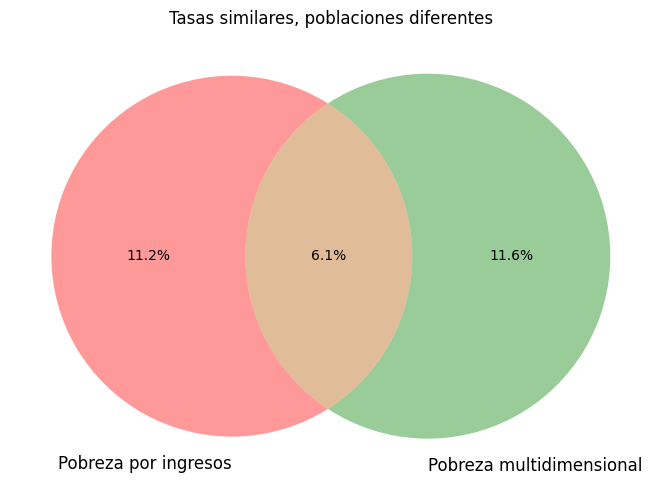

Pobreza por ingresos: 17.29%
Pobreza multidimensional: 17.68%
Intersección: 6.08%


In [36]:
# ============================================================
# 18. FIGURA 1 — SOLAPAMIENTO DE POBREZA EN PERSONAS
# ============================================================

# Tasas ponderadas en personas
p_ing = weighted_mean(
    d["pobre_ing_bin"],
    d["expr"]
)

p_multi = weighted_mean(
    d["pobre_multi_bin"],
    d["expr"]
)

p_both = weighted_mean(
    d["pobre_severa_interseccion"],
    d["expr"]
)

solo_ing = max(
    p_ing - p_both,
    0
)

solo_multi = max(
    p_multi - p_both,
    0
)

fig = plt.figure(
    figsize=(8.2, 5.0)
)

v = venn2(
    subsets=(
        solo_ing,
        solo_multi,
        p_both
    ),
    set_labels=(
        "Pobreza por ingresos",
        "Pobreza multidimensional"
    )
)

# Mostrar porcentajes, no proporciones
for patch_id, value in [
    ("10", solo_ing),
    ("01", solo_multi),
    ("11", p_both)
]:
    label = v.get_label_by_id(
        patch_id
    )
    if label is not None:
        label.set_text(
            f"{100*value:.1f}%"
        )

plt.title(
    "Tasas similares, poblaciones diferentes"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIG_DIR,
        "01_solapamiento_pobreza_personas.png"
    ),
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.08
)

plt.show()

print(
    f"Pobreza por ingresos: {100*p_ing:.2f}%"
)
print(
    f"Pobreza multidimensional: {100*p_multi:.2f}%"
)
print(
    f"Intersección: {100*p_both:.2f}%"
)

# PARTE III — Universo de análisis para PCA y K-Means

A partir de este punto se trabaja **exclusivamente con hogares pobres multidimensionales**.

Las variables se organizan en cuatro dimensiones:

- Educación
- Salud
- Vivienda
- Redes y cohesión social

La composición demográfica —edad, niños y adultos mayores— se reserva para **caracterizar** los perfiles y no define directamente la partición.

In [37]:
# ============================================================
# 19. DEFINIR VARIABLES SUSTANTIVAS
# ============================================================

def usable(c):
    return (
        c in hog.columns
        and hog[c].notna().mean() >= 0.05
        and hog[c].nunique(
            dropna=True
        ) >= 2
    )


# Educación
CL_EDU_NUM = [
    c for c in [
        "esc_media_adultos"
    ]
    if usable(c)
]

# Salud
CL_HEALTH_NUM = [
    c for c in [
        "prop_problema_salud_hogar",
        "prop_sin_prevision_salud",
        "prop_barreras_acceso_salud"
    ]
    if usable(c)
]

# Vivienda
CL_HOUSING_NUM = [
    c for c in [
        "personas_por_dormitorio",
        "personas_por_bano"
    ]
    if usable(c)
]

housing_cat_candidates = [
    "v2",
    "v3",
    "v4",
    "v5",
    "v6",
    "v7",
    "v12",
    "v13"
]

CL_HOUSING_CAT = [
    c for c in housing_cat_candidates
    if usable(c)
]

# Redes / cohesión
CL_NETWORK_NUM = [
    c for c in [
        "apoyo_score",
        "inseguridad_alimentaria_n",
        "participa_organizacion"
    ]
    if usable(c)
]


cluster_variable_table = []

for dim, vars_dim in [
    ("Educación", CL_EDU_NUM),
    ("Salud", CL_HEALTH_NUM),
    ("Vivienda", CL_HOUSING_NUM + CL_HOUSING_CAT),
    ("Redes y cohesión social", CL_NETWORK_NUM)
]:

    for c in vars_dim:
        cluster_variable_table.append(
            {
                "Dimensión": dim,
                "Variable": nombre_variable(c)
            }
        )


cluster_variable_table = (
    pd.DataFrame(
        cluster_variable_table
    )
    .drop_duplicates()
    .reset_index(drop=True)
)

display(
    cluster_variable_table
)

cluster_variable_table.to_csv(
    os.path.join(
        RESULTS_DIR,
        "04_variables_analisis.csv"
    ),
    index=False
)

,Dimensión,Variable
0,Educación,Años promedio de escolaridad de los adultos
1,Salud,Proporción de integrantes con problema de salu...
2,Salud,Proporción de integrantes sin sistema previsio...
3,Salud,Incidencia promedio de barreras de acceso a at...
4,Vivienda,Personas por dormitorio
5,Vivienda,Personas por baño
6,Vivienda,¿Cuál es el material que predomina en los muro...
7,Vivienda,¿Cómo diría usted que es el estado de conserva...
8,Vivienda,¿Cuál es el material que predomina en el piso ...
9,Vivienda,¿Cómo diría usted que es el estado de conserva...


In [38]:
# ============================================================
# 20. MUESTRA DE HOGARES POBRES MULTIDIMENSIONALES
# ============================================================

pobres = (
    hog[
        hog["pobre_multi_bin"] == 1
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    "Hogares pobres multidimensionales:",
    len(pobres)
)

print(
    "Peso expandido:",
    round(
        pobres["expr"].sum(),
        0
    )
)

Hogares pobres multidimensionales: 10421
Peso expandido: 938821.0


# PARTE IV — Herramienta 1: Análisis de Componentes Principales (PCA)

El PCA se utiliza como herramienta **exploratoria y de representación**.

Su objetivo no es definir la pobreza ni reemplazar K-Means, sino responder:

> **¿Cómo se organiza la variabilidad de las condiciones de bienestar y qué variables estructuran los primeros componentes?**

Para facilitar la interpretación, el PCA se aplica a indicadores numéricos sustantivos de las cuatro dimensiones. Las variables se imputan por mediana y se estandarizan antes del análisis.

La proyección PC1–PC2 se utilizará posteriormente para visualizar los perfiles encontrados por K-Means.

In [39]:
# ============================================================
# 21. PREPARAR VARIABLES PARA PCA
# ============================================================

PCA_VARS = [
    c for c in [
        # Educación
        "esc_media_adultos",

        # Salud
        "prop_problema_salud_hogar",
        "prop_sin_prevision_salud",
        "prop_barreras_acceso_salud",

        # Vivienda
        "personas_por_dormitorio",
        "personas_por_bano",

        # Redes
        "apoyo_score",
        "inseguridad_alimentaria_n",
        "participa_organizacion"
    ]
    if usable(c)
]


pca_imputer = SimpleImputer(
    strategy="median"
)

pca_scaler = StandardScaler()


X_pca_imp = pca_imputer.fit_transform(
    pobres[
        PCA_VARS
    ]
)

X_pca_std = pca_scaler.fit_transform(
    X_pca_imp
)


ncomp = min(
    PCA_N_COMPONENTS,
    X_pca_std.shape[1]
)


pca_model = PCA(
    n_components=ncomp,
    random_state=RANDOM_STATE
)

pca_scores = pca_model.fit_transform(
    X_pca_std
)


for j in range(
    pca_scores.shape[1]
):
    pobres[
        f"PC{j+1}"
    ] = pca_scores[:, j]


pca_variance = pd.DataFrame(
    {
        "Componente": [
            f"PC{i+1}"
            for i in range(
                ncomp
            )
        ],
        "Varianza explicada":
            pca_model.explained_variance_ratio_,
        "Varianza acumulada":
            np.cumsum(
                pca_model.explained_variance_ratio_
            )
    }
)


display(
    pca_variance.assign(
        **{
            "Varianza explicada":
                100*pca_variance[
                    "Varianza explicada"
                ],
            "Varianza acumulada":
                100*pca_variance[
                    "Varianza acumulada"
                ]
        }
    ).round(2)
)


pca_variance.to_csv(
    os.path.join(
        RESULTS_DIR,
        "05_pca_varianza_explicada.csv"
    ),
    index=False
)

,Componente,Varianza explicada,Varianza acumulada
0,PC1,19.78,19.78
1,PC2,13.16,32.94
2,PC3,12.35,45.28
3,PC4,11.11,56.40
4,PC5,10.47,66.87
5,PC6,10.04,76.91


In [40]:
# ============================================================
# 22. CARGAS DEL PCA
# ============================================================

loadings = pd.DataFrame(
    pca_model.components_.T,
    index=[
        nombre_variable(c)
        for c in PCA_VARS
    ],
    columns=[
        f"PC{i+1}"
        for i in range(
            ncomp
        )
    ]
)

display(
    loadings[
        ["PC1", "PC2"]
    ].round(3)
)

loadings.to_csv(
    os.path.join(
        RESULTS_DIR,
        "06_pca_cargas.csv"
    )
)

,PC1,PC2
Años promedio de escolaridad de los adultos,0.240,0.218
Proporción de integrantes con problema de salud reciente,-0.330,0.372
Proporción de integrantes sin sistema previsional de salud,0.041,-0.295
Incidencia promedio de barreras de acceso a atención de salud,-0.226,0.296
Personas por dormitorio,0.573,-0.011
Personas por baño,0.603,0.087
Disponibilidad promedio de redes de apoyo,0.191,0.538
Número de situaciones de inseguridad alimentaria,-0.205,-0.261
Participación en organizaciones o grupos,-0.100,0.523


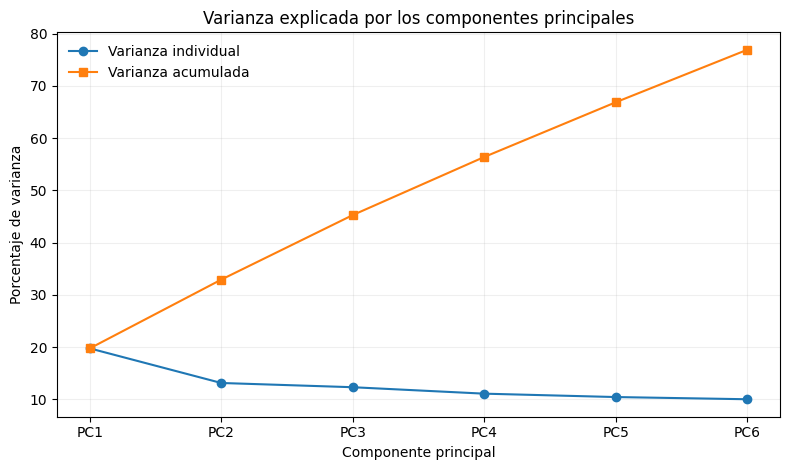

In [41]:
# ============================================================
# 23. FIGURA 2 — SCREE PLOT DEL PCA
# ============================================================

fig = plt.figure(
    figsize=(8.0, 4.8)
)

x = np.arange(
    1,
    len(pca_variance) + 1
)

plt.plot(
    x,
    100*pca_variance[
        "Varianza explicada"
    ],
    marker="o",
    label="Varianza individual"
)

plt.plot(
    x,
    100*pca_variance[
        "Varianza acumulada"
    ],
    marker="s",
    label="Varianza acumulada"
)

plt.xticks(
    x,
    [
        f"PC{i}"
        for i in x
    ]
)

plt.xlabel(
    "Componente principal"
)

plt.ylabel(
    "Porcentaje de varianza"
)

plt.title(
    "Varianza explicada por los componentes principales"
)

plt.legend(
    frameon=False
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIG_DIR,
        "02_pca_scree.png"
    ),
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.08
)

plt.show()

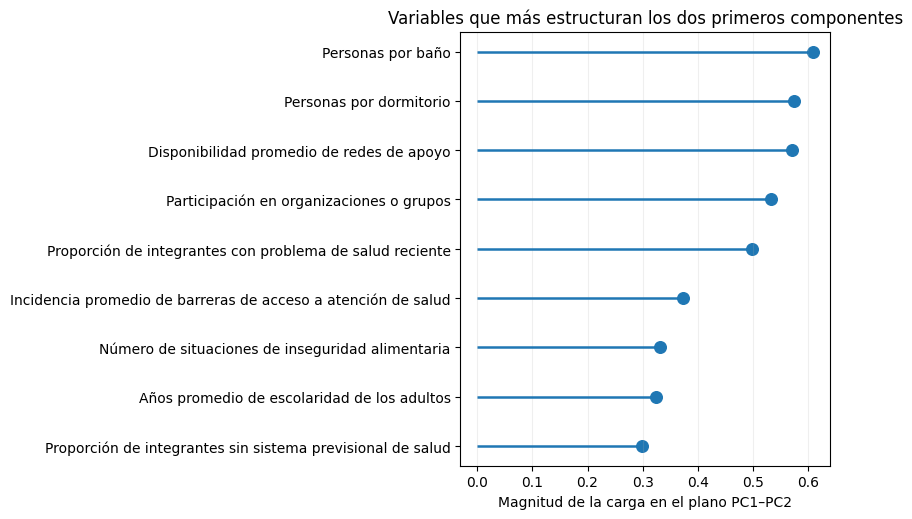

In [42]:
# ============================================================
# 24. FIGURA 3 — CONTRIBUCIÓN A PC1 Y PC2
# ============================================================

pc12 = loadings[
    ["PC1", "PC2"]
].copy()

# Magnitud conjunta en los dos primeros componentes
pc12[
    "Magnitud"
] = np.sqrt(
    pc12["PC1"]**2
    + pc12["PC2"]**2
)

pc12 = (
    pc12
    .sort_values(
        "Magnitud",
        ascending=True
    )
)


fig = plt.figure(
    figsize=(8.5, 5.3)
)

y = np.arange(
    len(pc12)
)

plt.hlines(
    y,
    xmin=0,
    xmax=pc12[
        "Magnitud"
    ],
    linewidth=1.8
)

plt.scatter(
    pc12[
        "Magnitud"
    ],
    y,
    s=70
)

plt.yticks(
    y,
    pc12.index
)

plt.xlabel(
    "Magnitud de la carga en el plano PC1–PC2"
)

plt.title(
    "Variables que más estructuran los dos primeros componentes"
)

plt.grid(
    axis="x",
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIG_DIR,
        "03_pca_contribucion_pc1_pc2.png"
    ),
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.08
)

plt.show()

# PARTE V — Herramienta 2: K-Means

K-Means es la herramienta principal para identificar perfiles dentro de los hogares pobres multidimensionales.

La especificación busca evitar que una dimensión domine mecánicamente:

1. cada variable numérica se estandariza;
2. cada variable categórica se transforma mediante *one-hot encoding*;
3. las categorías generadas por una misma pregunta se normalizan como un solo bloque;
4. cada dimensión recibe un peso global aproximadamente equivalente.

La solución final se fija en \(K=2\), pero se reportan diagnósticos para \(K=2,\ldots,7\).

In [43]:
# ============================================================
# 33. PREPROCESAMIENTO BALANCEADO EN DOS NIVELES — V4
# ============================================================

def transform_numeric_variable(
    data,
    variable,
    dimension
):

    pipe = Pipeline(
        [
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),
            (
                "scaler",
                StandardScaler()
            )
        ]
    )

    arr = pipe.fit_transform(
        data[[variable]]
    )

    names = [
        f"{dimension}__{variable}"
    ]

    groups = [
        variable
    ]

    return (
        np.asarray(arr, dtype=float),
        names,
        groups
    )


def transform_categorical_variable(
    data,
    variable,
    dimension
):

    pipe = Pipeline(
        [
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    min_frequency=0.005,
                    sparse_output=False
                )
            )
        ]
    )

    arr = np.asarray(
        pipe.fit_transform(
            data[[variable]]
        ),
        dtype=float
    )

    encoder = pipe.named_steps[
        "onehot"
    ]

    raw_names = encoder.get_feature_names_out(
        [variable]
    )

    # Balance dentro de la pregunta:
    # muchas categorías no deben dar más peso a esta pregunta.
    if arr.shape[1] > 0:
        arr = (
            arr
            / np.sqrt(
                arr.shape[1]
            )
        )

    names = [
        f"{dimension}__{x}"
        for x in raw_names
    ]

    groups = [
        variable
    ] * len(names)

    return (
        arr,
        names,
        groups
    )


def build_balanced_dimension(
    data,
    numeric_cols,
    categorical_cols,
    dimension
):

    blocks = []
    names = []
    groups = []

    # Cada variable numérica constituye una unidad sustantiva.
    for c in numeric_cols:

        arr, nms, gps = (
            transform_numeric_variable(
                data,
                c,
                dimension
            )
        )

        blocks.append(arr)
        names.extend(nms)
        groups.extend(gps)


    # Cada pregunta categórica constituye una unidad sustantiva.
    for c in categorical_cols:

        arr, nms, gps = (
            transform_categorical_variable(
                data,
                c,
                dimension
            )
        )

        blocks.append(arr)
        names.extend(nms)
        groups.extend(gps)


    if len(blocks) == 0:

        return (
            np.empty(
                (
                    len(data),
                    0
                )
            ),
            [],
            [],
            0
        )


    arr = np.hstack(
        blocks
    )


    # Balance entre variables/preguntas dentro de la dimensión.
    n_original_variables = len(blocks)

    arr = (
        arr
        / np.sqrt(
            n_original_variables
        )
    )


    return (
        arr,
        names,
        groups,
        n_original_variables
    )


In [44]:
# ============================================================
# 34. CONSTRUIR LAS 4 DIMENSIONES — V4
# ============================================================

edu_arr, edu_names, edu_groups, edu_q = (
    build_balanced_dimension(
        pobres,
        numeric_cols=CL_EDU_NUM,
        categorical_cols=[],
        dimension="Educacion"
    )
)


health_arr, health_names, health_groups, health_q = (
    build_balanced_dimension(
        pobres,
        numeric_cols=CL_HEALTH_NUM,
        categorical_cols=[],
        dimension="Salud"
    )
)


housing_arr, housing_names, housing_groups, housing_q = (
    build_balanced_dimension(
        pobres,
        numeric_cols=CL_HOUSING_NUM,
        categorical_cols=CL_HOUSING_CAT,
        dimension="Vivienda"
    )
)


network_arr, network_names, network_groups, network_q = (
    build_balanced_dimension(
        pobres,
        numeric_cols=CL_NETWORK_NUM,
        categorical_cols=[],
        dimension="Redes"
    )
)


# Las dimensiones ya vienen balanceadas internamente.
# Ahora se concatenan. Cada una tiene aproximadamente el mismo
# peso esperado porque fue dividida por sqrt(q_d).

X_cluster = np.hstack(
    [
        edu_arr,
        health_arr,
        housing_arr,
        network_arr
    ]
)


cluster_feature_names = (
    edu_names
    + health_names
    + housing_names
    + network_names
)


cluster_groups = (
    edu_groups
    + health_groups
    + housing_groups
    + network_groups
)


dimensiones_transformadas = pd.DataFrame(
    {
        "Dimensión": [
            "Educación",
            "Salud",
            "Vivienda",
            "Redes y cohesión social"
        ],
        "Variables/preguntas originales": [
            edu_q,
            health_q,
            housing_q,
            network_q
        ],
        "Columnas transformadas": [
            edu_arr.shape[1],
            health_arr.shape[1],
            housing_arr.shape[1],
            network_arr.shape[1]
        ]
    }
)


print(
    "Matriz final del clustering V4:",
    X_cluster.shape
)

display(
    dimensiones_transformadas
)


Matriz final del clustering V4: (10421, 47)


,Dimensión,Variables/preguntas originales,Columnas transformadas
0,Educación,1,1
1,Salud,3,3
2,Vivienda,10,40
3,Redes y cohesión social,3,3


In [45]:
# ============================================================
# 27. DIAGNÓSTICO DEL NÚMERO DE CLUSTERS
# ============================================================

weights_poor = (
    pobres["expr"]
    .astype(float)
    .to_numpy()
)

weights_poor = (
    weights_poor
    / np.mean(
        weights_poor
    )
)


# Muestra fija para métricas que no aceptan pesos
rng = np.random.default_rng(
    RANDOM_STATE
)

metric_sample_n = min(
    7000,
    len(pobres)
)

metric_idx = rng.choice(
    len(pobres),
    size=metric_sample_n,
    replace=False
)


cluster_eval_rows = []
models_k = {}


for k in range(
    K_MIN,
    K_MAX + 1
):

    km = KMeans(
        n_clusters=k,
        n_init=30,
        random_state=RANDOM_STATE
    )

    km.fit(
        X_cluster,
        sample_weight=weights_poor
    )

    labels = km.labels_

    models_k[k] = km

    sil = silhouette_score(
        X_cluster[
            metric_idx
        ],
        labels[
            metric_idx
        ]
    )

    ch = calinski_harabasz_score(
        X_cluster[
            metric_idx
        ],
        labels[
            metric_idx
        ]
    )

    cluster_weight = (
        pd.Series(
            weights_poor
        )
        .groupby(
            labels
        )
        .sum()
    )

    min_cluster_pct = (
        100
        * cluster_weight.min()
        / cluster_weight.sum()
    )

    cluster_eval_rows.append(
        {
            "K": k,
            "Inercia":
                km.inertia_,
            "Silhouette":
                sil,
            "Calinski-Harabasz":
                ch,
            "% cluster más pequeño":
                min_cluster_pct
        }
    )


cluster_eval = pd.DataFrame(
    cluster_eval_rows
)

display(
    cluster_eval.round(4)
)

cluster_eval.to_csv(
    os.path.join(
        RESULTS_DIR,
        "07_seleccion_k.csv"
    ),
    index=False
)

,K,Inercia,Silhouette,Calinski-Harabasz,% cluster más pequeño
0,2,27669.1118,0.1870,1725.3186,34.3049
1,3,24960.8771,0.1963,1300.3661,3.1814
2,4,22711.7757,0.1588,1194.2587,3.1678
3,5,20869.0731,0.1610,1121.3242,2.9957
4,6,19498.8631,0.1470,1043.1345,2.9092
5,7,18283.6427,0.1418,990.4299,2.8812


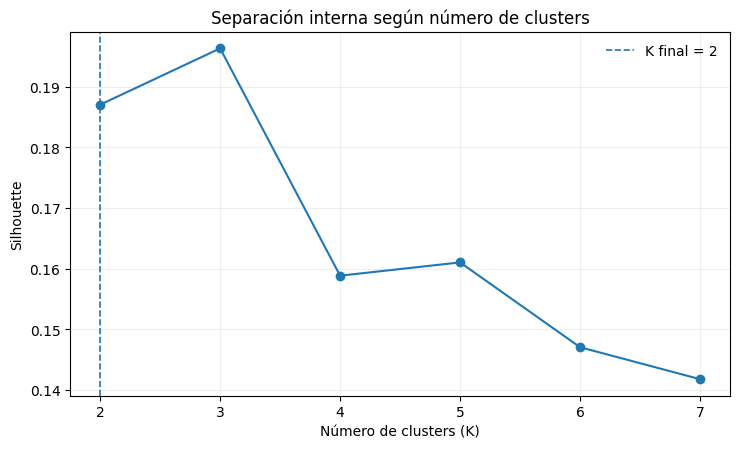

In [46]:
# ============================================================
# 28. FIGURA 4 — SELECCIÓN DE K: SILHOUETTE
# ============================================================

fig = plt.figure(
    figsize=(7.5, 4.6)
)

plt.plot(
    cluster_eval["K"],
    cluster_eval["Silhouette"],
    marker="o"
)

plt.axvline(
    K_FINAL,
    linestyle="--",
    linewidth=1.2,
    label=f"K final = {K_FINAL}"
)

plt.xlabel(
    "Número de clusters (K)"
)

plt.ylabel(
    "Silhouette"
)

plt.title(
    "Separación interna según número de clusters"
)

plt.legend(
    frameon=False
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIG_DIR,
        "04_kmeans_silhouette.png"
    ),
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.08
)

plt.show()

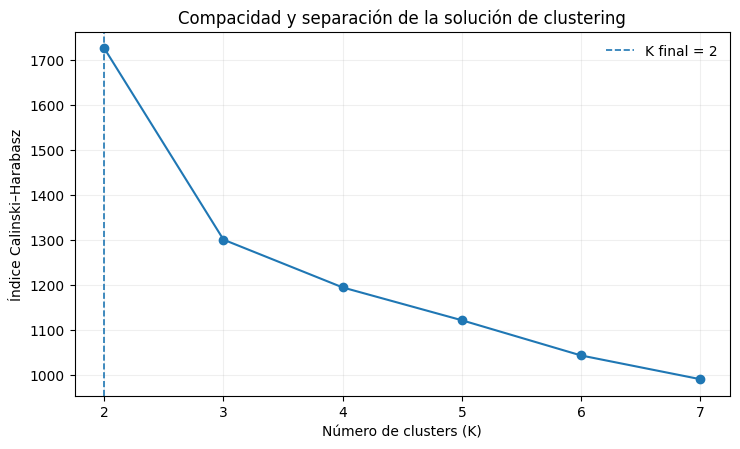

In [47]:
# ============================================================
# 29. FIGURA 5 — SELECCIÓN DE K: CALINSKI–HARABASZ
# ============================================================

fig = plt.figure(
    figsize=(7.5, 4.6)
)

plt.plot(
    cluster_eval["K"],
    cluster_eval[
        "Calinski-Harabasz"
    ],
    marker="o"
)

plt.axvline(
    K_FINAL,
    linestyle="--",
    linewidth=1.2,
    label=f"K final = {K_FINAL}"
)

plt.xlabel(
    "Número de clusters (K)"
)

plt.ylabel(
    "Índice Calinski–Harabasz"
)

plt.title(
    "Compacidad y separación de la solución de clustering"
)

plt.legend(
    frameon=False
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIG_DIR,
        "05_kmeans_calinski_harabasz.png"
    ),
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.08
)

plt.show()

In [48]:
# ============================================================
# 30. AJUSTE FINAL DE K-MEANS
# ============================================================

kmeans = models_k[
    K_FINAL
]

pobres[
    "cluster_kmeans"
] = (
    kmeans.labels_
)


# Etiquetas interpretables y robustas a permutación de IDs.
edu_cluster = (
    pobres.groupby(
        "cluster_kmeans"
    )
    .apply(
        lambda g:
            weighted_mean(
                g[
                    "esc_media_adultos"
                ],
                g["expr"]
            )
    )
)


CLUSTER_BAJA_EDU = int(
    edu_cluster.idxmin()
)

CLUSTER_OTRO = int(
    edu_cluster.idxmax()
)


PROFILE_LABELS = {
    CLUSTER_BAJA_EDU:
        "Perfil A: menor capital educativo",
    CLUSTER_OTRO:
        "Perfil B: mayor presión habitacional"
}


pobres[
    "perfil_kmeans"
] = (
    pobres[
        "cluster_kmeans"
    ]
    .map(
        PROFILE_LABELS
    )
)


cluster_size = (
    pobres.groupby(
        [
            "cluster_kmeans",
            "perfil_kmeans"
        ],
        as_index=False
    )
    .apply(
        lambda g:
            pd.Series(
                {
                    "Número de hogares":
                        len(g),
                    "% ponderado":
                        100
                        * g["expr"].sum()
                        / pobres[
                            "expr"
                        ].sum()
                }
            ),
        include_groups=False
    )
    .reset_index()
)


display(
    cluster_size
)

cluster_size.to_csv(
    os.path.join(
        RESULTS_DIR,
        "08_tamano_clusters.csv"
    ),
    index=False
)

,index,cluster_kmeans,perfil_kmeans,Número de hogares,% ponderado
0,0,0,Perfil A: menor capital educativo,4247.0,34.304942
1,1,1,Perfil B: mayor presión habitacional,6174.0,65.695058


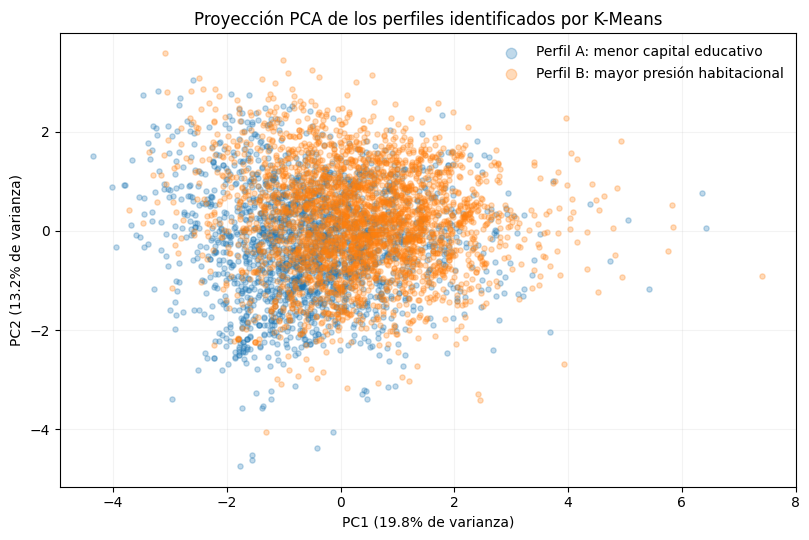

In [49]:
# ============================================================
# 31. FIGURA 6 — PCA: PROYECCIÓN PC1–PC2 Y PERFILES K-MEANS
# ============================================================

plot_df = pobres[
    [
        "PC1",
        "PC2",
        "perfil_kmeans"
    ]
].dropna().copy()


if len(plot_df) > PCA_SCATTER_SAMPLE:

    plot_df = plot_df.sample(
        PCA_SCATTER_SAMPLE,
        random_state=RANDOM_STATE
    )


fig = plt.figure(
    figsize=(8.2, 5.5)
)


for perfil, g in plot_df.groupby(
    "perfil_kmeans"
):

    plt.scatter(
        g["PC1"],
        g["PC2"],
        s=14,
        alpha=0.28,
        label=perfil
    )


plt.xlabel(
    f"PC1 ({100*pca_model.explained_variance_ratio_[0]:.1f}% de varianza)"
)

plt.ylabel(
    f"PC2 ({100*pca_model.explained_variance_ratio_[1]:.1f}% de varianza)"
)

plt.title(
    "Proyección PCA de los perfiles identificados por K-Means"
)

plt.legend(
    frameon=False,
    markerscale=2
)

plt.grid(
    alpha=0.15
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIG_DIR,
        "06_pca_clusters_pc1_pc2.png"
    ),
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.08
)

plt.show()

# PARTE VI — Caracterización de los perfiles

Los clusters no se interpretan automáticamente como “mejor” y “peor”.

Se comparan sus características en Educación, Salud, Vivienda, Redes y composición demográfica. La edad y estructura del hogar se utilizan aquí como **descripción ex post**, no como variables que formaron los clusters.

In [50]:
# ============================================================
# 32. PERFIL PONDERADO DE LOS CLUSTERS
# ============================================================

PROFILE_VARS = [
    c for c in [
        # Educación
        "esc_jefe",
        "esc_media_adultos",
        "prop_asiste_4_24",

        # Salud
        "prop_problema_salud_hogar",
        "prop_sin_prevision_salud",
        "prop_barreras_acceso_salud",

        # Vivienda
        "personas_por_dormitorio",
        "personas_por_bano",

        # Redes
        "apoyo_score",
        "inseguridad_alimentaria_n",
        "participa_organizacion",

        # Demografía
        "edad_jefe",
        "edad_media",
        "prop_ninos",
        "prop_mayores",

        # Validación externa
        "pobre_ing_bin"
    ]
    if c in pobres.columns
]


profile_rows = []


for perfil, g in pobres.groupby(
    "perfil_kmeans"
):

    row = {
        "Perfil": perfil,
        "Número de hogares":
            len(g),
        "% ponderado":
            100
            * g["expr"].sum()
            / pobres[
                "expr"
            ].sum()
    }

    for c in PROFILE_VARS:

        row[
            nombre_variable(c)
        ] = weighted_mean(
            g[c],
            g["expr"]
        )

    profile_rows.append(
        row
    )


cluster_profile = pd.DataFrame(
    profile_rows
)

display(
    cluster_profile.round(3)
)

cluster_profile.to_csv(
    os.path.join(
        RESULTS_DIR,
        "09_perfil_clusters.csv"
    ),
    index=False
)

,Perfil,Número de hogares,% ponderado,Años de escolaridad de la jefatura del hogar,Años promedio de escolaridad de los adultos,Proporción de personas de 4 a 24 años que asiste a educación,Proporción de integrantes con problema de salud reciente,Proporción de integrantes sin sistema previsional de salud,Incidencia promedio de barreras de acceso a atención de salud,Personas por dormitorio,Personas por baño,Disponibilidad promedio de redes de apoyo,Número de situaciones de inseguridad alimentaria,Participación en organizaciones o grupos,Edad de la jefatura del hogar,Edad promedio de los integrantes del hogar,Proporción de menores de 18 años,Proporción de personas de 65 años o más,Pobreza por ingresos
0,Perfil A: menor capital educativo,4247,34.305,6.105,6.628,0.749,0.252,0.039,0.264,1.424,3.077,0.625,3.710,0.331,58.541,47.042,0.156,0.235,0.406
1,Perfil B: mayor presión habitacional,6174,65.695,11.792,12.211,0.775,0.251,0.032,0.244,1.650,3.520,0.685,3.518,0.314,47.849,33.146,0.263,0.074,0.342


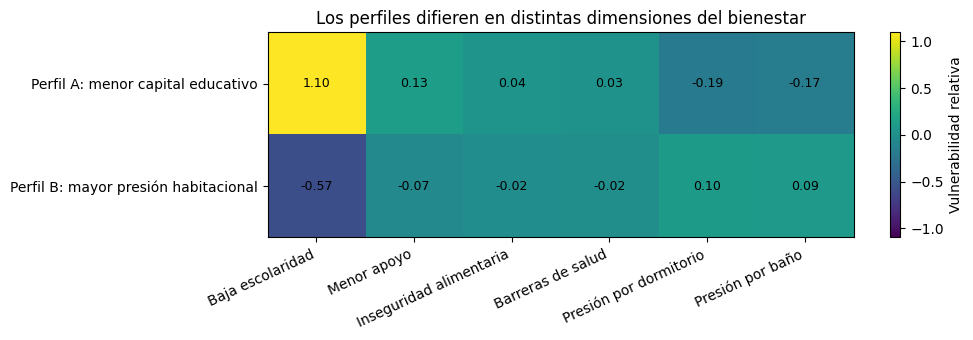

In [51]:
# ============================================================
# 33. FIGURA 7 — HEATMAP DE VULNERABILIDAD RELATIVA
# ============================================================

profile_heat_vars = {
    "esc_media_adultos":
        ("Baja escolaridad", -1),

    "apoyo_score":
        ("Menor apoyo", -1),

    "inseguridad_alimentaria_n":
        ("Inseguridad alimentaria", +1),

    "prop_barreras_acceso_salud":
        ("Barreras de salud", +1),

    "personas_por_dormitorio":
        ("Presión por dormitorio", +1),

    "personas_por_bano":
        ("Presión por baño", +1)
}


heat_rows = []


for variable, (
    label,
    direction
) in profile_heat_vars.items():

    mu = weighted_mean(
        pobres[
            variable
        ],
        pobres[
            "expr"
        ]
    )

    sd = np.sqrt(
        np.average(
            (
                pobres[
                    variable
                ].fillna(mu)
                - mu
            )**2,
            weights=pobres[
                "expr"
            ]
        )
    )

    z = (
        direction
        * (
            pobres[
                variable
            ].fillna(mu)
            - mu
        )
        / sd
    )


    temp = pobres[
        [
            "perfil_kmeans",
            "expr"
        ]
    ].copy()

    temp["z"] = z


    for perfil, g in temp.groupby(
        "perfil_kmeans"
    ):

        heat_rows.append(
            {
                "Perfil": perfil,
                "Indicador": label,
                "Vulnerabilidad relativa":
                    weighted_mean(
                        g["z"],
                        g["expr"]
                    )
            }
        )


heat_df = (
    pd.DataFrame(
        heat_rows
    )
    .pivot(
        index="Perfil",
        columns="Indicador",
        values="Vulnerabilidad relativa"
    )
)


order_cols = [
    "Baja escolaridad",
    "Menor apoyo",
    "Inseguridad alimentaria",
    "Barreras de salud",
    "Presión por dormitorio",
    "Presión por baño"
]

heat_df = heat_df[
    order_cols
]


fig = plt.figure(
    figsize=(10.2, 3.5)
)

lim = np.nanmax(
    np.abs(
        heat_df.values
    )
)

img = plt.imshow(
    heat_df.values,
    aspect="auto",
    vmin=-lim,
    vmax=lim
)

plt.xticks(
    np.arange(
        len(
            heat_df.columns
        )
    ),
    heat_df.columns,
    rotation=25,
    ha="right"
)

plt.yticks(
    np.arange(
        len(
            heat_df.index
        )
    ),
    heat_df.index
)


for i in range(
    heat_df.shape[0]
):

    for j in range(
        heat_df.shape[1]
    ):

        plt.text(
            j,
            i,
            f"{heat_df.iloc[i,j]:.2f}",
            ha="center",
            va="center",
            fontsize=9
        )


plt.colorbar(
    img,
    label="Vulnerabilidad relativa"
)

plt.title(
    "Los perfiles difieren en distintas dimensiones del bienestar"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIG_DIR,
        "07_perfil_clusters_heatmap.png"
    ),
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.08
)

plt.show()

# PARTE VII — Extensión complementaria: selección tipo Fraiman

Una vez obtenida una clusterización aceptable, se evalúa qué subconjunto de variables originales permite reproducirla.

El procedimiento exacto de Fraiman puede tener un costo computacional muy elevado. Por ello se utiliza una **aproximación forward sobre una submuestra**, en línea con la lógica del artículo.

Importante:

- no se utiliza Random Forest como pre-filtro;
- todos los grupos originales del clustering pueden ser candidatos;
- la tasa de reasignación mide qué proporción conserva el cluster original después del *blinding*;
- el objetivo es alcanzar al menos 90% de reasignación con el menor número de variables.

In [52]:
# ============================================================
# 34. MAPEO DE FEATURES PROCESADAS A VARIABLES ORIGINALES
# ============================================================

group_to_idx = {}

for j, g in enumerate(
    cluster_groups
):

    group_to_idx.setdefault(
        g,
        []
    ).append(
        j
    )


print(
    "Variables originales candidatas:",
    len(
        group_to_idx
    )
)

display(
    pd.DataFrame(
        {
            "Variable": [
                nombre_variable(g)
                for g in group_to_idx
            ],
            "Dimensión": [
                dimension_variable(g)
                for g in group_to_idx
            ]
        }
    )
)

Variables originales candidatas: 17


,Variable,Dimensión
0,Años promedio de escolaridad de los adultos,Educación
1,Proporción de integrantes con problema de salu...,Salud
2,Proporción de integrantes sin sistema previsio...,Salud
3,Incidencia promedio de barreras de acceso a at...,Salud
4,Personas por dormitorio,Vivienda
5,Personas por baño,Vivienda
6,¿Cuál es el material que predomina en los muro...,Vivienda
7,¿Cómo diría usted que es el estado de conserva...,Vivienda
8,¿Cuál es el material que predomina en el piso ...,Vivienda
9,¿Cómo diría usted que es el estado de conserva...,Vivienda


In [53]:
# ============================================================
# 35. FRAIMAN / BLINDING APROXIMADO SIN PRE-FILTRO
# ============================================================

fraiman_history = pd.DataFrame()


if RUN_FRAIMAN:

    candidate_groups = list(
        group_to_idx.keys()
    )

    # --------------------------------------------------------
    # Submuestra estratificada por cluster
    # --------------------------------------------------------

    pieces = []

    per_cluster = max(
        200,
        FRAIMAN_SAMPLE_N
        // K_FINAL
    )


    for cl, g in pobres.groupby(
        "cluster_kmeans"
    ):

        take_n = min(
            per_cluster,
            len(g)
        )

        pieces.append(
            g.sample(
                n=take_n,
                random_state=(
                    RANDOM_STATE
                    + int(cl)
                )
            )
        )


    sample_df = pd.concat(
        pieces
    )

    sample_idx = (
        sample_df.index
        .to_numpy()
    )


    Xf = np.asarray(
        X_cluster[
            sample_idx
        ],
        dtype=float
    )


    y_cluster_f = (
        pobres.loc[
            sample_idx,
            "cluster_kmeans"
        ]
        .to_numpy()
    )


    wf = (
        pobres.loc[
            sample_idx,
            "expr"
        ]
        .to_numpy(
            dtype=float
        )
    )

    wf = (
        wf
        / np.mean(
            wf
        )
    )


    all_idx = np.arange(
        Xf.shape[1]
    )


    def indices_groups(
        selected_groups
    ):

        idx = []

        for g in selected_groups:

            idx.extend(
                group_to_idx[
                    g
                ]
            )

        return sorted(
            set(idx)
        )


    def fraiman_agreement(
        selected_groups
    ):

        selected_idx = indices_groups(
            selected_groups
        )

        not_selected_idx = np.setdiff1d(
            all_idx,
            selected_idx
        )


        Z = Xf.copy()


        if len(
            not_selected_idx
        ) == 0:

            new_cluster = kmeans.predict(
                Z
            )

            return np.average(
                new_cluster
                == y_cluster_f,
                weights=wf
            )


        if len(
            selected_idx
        ) == 0:

            Z[
                :,
                not_selected_idx
            ] = np.nanmean(
                Xf[
                    :,
                    not_selected_idx
                ],
                axis=0
            )


        else:

            n_neighbors = min(
                FRAIMAN_NEIGHBORS,
                max(
                    2,
                    len(Xf) - 1
                )
            )


            knn = KNeighborsRegressor(
                n_neighbors=n_neighbors,
                weights="distance",
                n_jobs=-1
            )


            knn.fit(
                Xf[
                    :,
                    selected_idx
                ],
                Xf[
                    :,
                    not_selected_idx
                ]
            )


            Z[
                :,
                not_selected_idx
            ] = knn.predict(
                Xf[
                    :,
                    selected_idx
                ]
            )


        new_cluster = kmeans.predict(
            Z
        )


        return np.average(
            new_cluster
            == y_cluster_f,
            weights=wf
        )


    # --------------------------------------------------------
    # Selección forward
    # --------------------------------------------------------

    selected = []
    remaining = candidate_groups.copy()
    history = []


    while remaining:

        scores = []

        for g in remaining:

            score = fraiman_agreement(
                selected
                + [g]
            )

            scores.append(
                (
                    g,
                    score
                )
            )


        best_group, best_score = max(
            scores,
            key=lambda x: x[1]
        )


        selected.append(
            best_group
        )

        remaining.remove(
            best_group
        )


        history.append(
            {
                "Paso":
                    len(selected),
                "Variable agregada":
                    nombre_variable(
                        best_group
                    ),
                "Dimensión":
                    dimension_variable(
                        best_group
                    ),
                "Tasa de reasignación":
                    best_score,
                "Variables seleccionadas":
                    " | ".join(
                        nombre_variable(x)
                        for x in selected
                    )
            }
        )


        print(
            f"Paso {len(selected):02d}"
            f" | {nombre_variable(best_group)}"
            f" | reasignación={best_score:.4f}"
        )


        if (
            best_score
            >= FRAIMAN_TARGET_AGREEMENT
        ):
            break


    fraiman_history = pd.DataFrame(
        history
    )


    display(
        fraiman_history
    )


    fraiman_history.to_csv(
        os.path.join(
            RESULTS_DIR,
            "10_fraiman_blinding.csv"
        ),
        index=False
    )


else:

    print(
        "RUN_FRAIMAN=False"
    )

Paso 01 | Años promedio de escolaridad de los adultos | reasignación=0.9863


,Paso,Variable agregada,Dimensión,Tasa de reasignación,Variables seleccionadas
0,1,Años promedio de escolaridad de los adultos,Educación,0.98631,Años promedio de escolaridad de los adultos


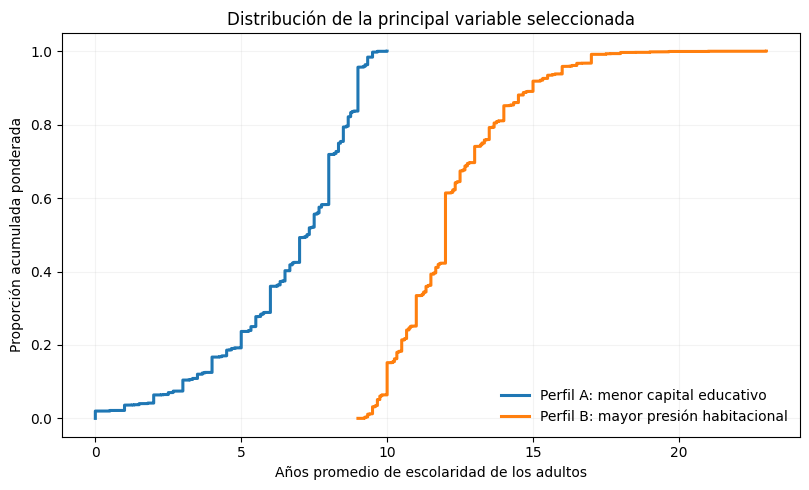

In [54]:
# ============================================================
# 36. FIGURA 8 — DISTRIBUCIÓN DE LA VARIABLE SELECCIONADA
# ============================================================

def weighted_ecdf(
    x,
    w
):

    x = np.asarray(x)
    w = np.asarray(w)

    valid = (
        np.isfinite(x)
        & np.isfinite(w)
        & (w > 0)
    )

    x = x[valid]
    w = w[valid]

    order = np.argsort(
        x
    )

    x = x[order]
    w = w[order]

    cdf = np.cumsum(
        w
    ) / np.sum(
        w
    )

    return (
        x,
        cdf
    )


if (
    RUN_FRAIMAN
    and len(
        fraiman_history
    ) > 0
):

    selected_name = fraiman_history[
        "Variable agregada"
    ].iloc[0]

    # Buscar código interno a partir del nombre mostrado.
    first_group = None

    for g in group_to_idx:

        if (
            nombre_variable(g)
            == selected_name
        ):

            first_group = g
            break


    # Solo generamos ECDF si la primera variable es numérica.
    if (
        first_group is not None
        and first_group
        in pobres.columns
        and pd.api.types.is_numeric_dtype(
            pobres[
                first_group
            ]
        )
    ):

        fig = plt.figure(
            figsize=(8.2, 5.0)
        )

        for perfil, g in pobres.groupby(
            "perfil_kmeans"
        ):

            x_ecdf, y_ecdf = weighted_ecdf(
                g[
                    first_group
                ],
                g[
                    "expr"
                ]
            )

            plt.step(
                x_ecdf,
                y_ecdf,
                where="post",
                linewidth=2.2,
                label=perfil
            )


        plt.xlabel(
            nombre_variable(
                first_group
            )
        )

        plt.ylabel(
            "Proporción acumulada ponderada"
        )

        plt.title(
            "Distribución de la principal variable seleccionada"
        )

        plt.legend(
            frameon=False
        )

        plt.grid(
            alpha=0.15
        )

        plt.tight_layout()

        plt.savefig(
            os.path.join(
                FIG_DIR,
                "08_fraiman_variable_ecdf.png"
            ),
            dpi=300,
            bbox_inches="tight",
            pad_inches=0.08
        )

        plt.show()

    else:

        print(
            "La primera variable seleccionada no es numérica; "
            "se omite la ECDF."
        )

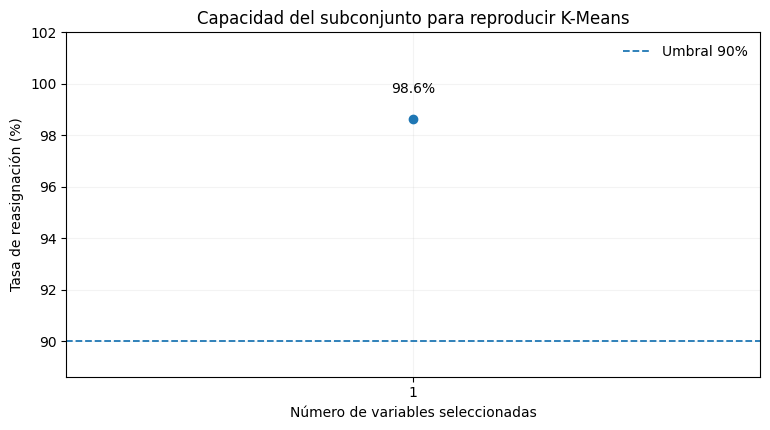

In [55]:
# ============================================================
# 37. FIGURA 9 — TASA DE REASIGNACIÓN FRAIMAN
# ============================================================

if (
    RUN_FRAIMAN
    and len(
        fraiman_history
    ) > 0
):

    fig = plt.figure(
        figsize=(7.8, 4.4)
    )


    x = fraiman_history[
        "Paso"
    ].to_numpy()

    y = (
        100
        * fraiman_history[
            "Tasa de reasignación"
        ].to_numpy()
    )


    plt.plot(
        x,
        y,
        marker="o",
        linewidth=2
    )


    plt.axhline(
        100
        * FRAIMAN_TARGET_AGREEMENT,
        linestyle="--",
        linewidth=1.3,
        label=(
            f"Umbral "
            f"{100*FRAIMAN_TARGET_AGREEMENT:.0f}%"
        )
    )


    for xi, yi in zip(
        x,
        y
    ):

        plt.text(
            xi,
            yi + 1,
            f"{yi:.1f}%",
            ha="center"
        )


    plt.xticks(
        x
    )

    plt.xlabel(
        "Número de variables seleccionadas"
    )

    plt.ylabel(
        "Tasa de reasignación (%)"
    )

    plt.ylim(
        max(
            0,
            min(y) - 10
        ),
        102
    )

    plt.title(
        "Capacidad del subconjunto para reproducir K-Means"
    )

    plt.legend(
        frameon=False
    )

    plt.grid(
        alpha=0.15
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            FIG_DIR,
            "09_fraiman_reasignacion.png"
        ),
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.08
    )

    plt.show()

# PARTE VIII — Validación externa e interpretación

La clasificación de K-Means no se etiqueta automáticamente como pobreza “más” o “menos” severa.

Como validación externa se compara la proporción de hogares que también son pobres por ingresos en cada perfil. Esto permite evaluar si uno de los perfiles concentra mayor vulnerabilidad monetaria, sin asumir que sea peor en todas las dimensiones.

In [56]:
# ============================================================
# 38. VALIDACIÓN EXTERNA CON POBREZA POR INGRESOS
# ============================================================

validation_rows = []


for perfil, g in pobres.groupby(
    "perfil_kmeans"
):

    validation_rows.append(
        {
            "Perfil":
                perfil,
            "% también pobre por ingresos":
                100
                * weighted_mean(
                    g[
                        "pobre_ing_bin"
                    ],
                    g[
                        "expr"
                    ]
                )
        }
    )


validation = pd.DataFrame(
    validation_rows
)


display(
    validation.round(2)
)


validation.to_csv(
    os.path.join(
        RESULTS_DIR,
        "11_validacion_pobreza_ingresos.csv"
    ),
    index=False
)

,Perfil,% también pobre por ingresos
0,Perfil A: menor capital educativo,40.62
1,Perfil B: mayor presión habitacional,34.16


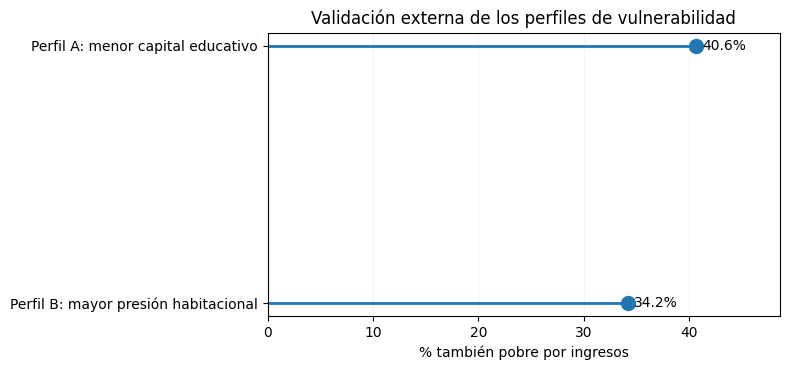

In [57]:
# ============================================================
# 39. FIGURA 10 — VALIDACIÓN EXTERNA
# ============================================================

validation_plot = (
    validation
    .sort_values(
        "% también pobre por ingresos"
    )
)


fig = plt.figure(
    figsize=(8.0, 3.8)
)


y = np.arange(
    len(
        validation_plot
    )
)

x = validation_plot[
    "% también pobre por ingresos"
].to_numpy()


plt.hlines(
    y,
    xmin=0,
    xmax=x,
    linewidth=2
)

plt.scatter(
    x,
    y,
    s=100
)


for yi, xi in zip(
    y,
    x
):

    plt.text(
        xi + 0.6,
        yi,
        f"{xi:.1f}%",
        va="center"
    )


plt.yticks(
    y,
    validation_plot[
        "Perfil"
    ]
)

plt.xlabel(
    "% también pobre por ingresos"
)

plt.title(
    "Validación externa de los perfiles de vulnerabilidad"
)

plt.xlim(
    0,
    max(x) + 8
)

plt.grid(
    axis="x",
    alpha=0.15
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIG_DIR,
        "10_validacion_pobreza_ingresos.png"
    ),
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.08
)

plt.show()

In [58]:
# ============================================================
# 40. GUARDAR BASES FINALES Y DICCIONARIOS
# ============================================================

# Llevar clasificación a la base hogar completa
cluster_assignments = pobres[
    [
        "folio",
        "cluster_kmeans",
        "perfil_kmeans"
    ]
].copy()


hog_final = hog.merge(
    cluster_assignments,
    on="folio",
    how="left"
)


hog_final.to_parquet(
    os.path.join(
        RESULTS_DIR,
        "12_base_hogar_final.parquet"
    ),
    index=False
)


pobres.to_parquet(
    os.path.join(
        RESULTS_DIR,
        "13_pobres_pca_kmeans.parquet"
    ),
    index=False
)


# Diccionario técnico
if (
    "diccionario_tecnico"
    in globals()
):

    diccionario_tecnico.to_csv(
        os.path.join(
            RESULTS_DIR,
            "00_diccionario_tecnico.csv"
        ),
        index=False
    )


print(
    "Archivos finales guardados."
)

Archivos finales guardados.


In [59]:
# ============================================================
# 41. RESUMEN AUTOMÁTICO
# ============================================================

summary = {
    "personas":
        int(
            len(d)
        ),
    "hogares":
        int(
            len(hog)
        ),
    "hogares_pobres_multidimensionales":
        int(
            len(pobres)
        ),
    "K_final":
        int(
            K_FINAL
        ),
    "pca_varianza_PC1_pct":
        float(
            100
            * pca_model.explained_variance_ratio_[0]
        ),
    "pca_varianza_PC2_pct":
        float(
            100
            * pca_model.explained_variance_ratio_[1]
        ),
    "pca_varianza_PC1_PC2_pct":
        float(
            100
            * pca_model.explained_variance_ratio_[:2].sum()
        ),
    "fraiman_n_variables":
        int(
            len(
                fraiman_history
            )
        )
        if (
            RUN_FRAIMAN
            and len(
                fraiman_history
            ) > 0
        )
        else 0,
    "fraiman_reasignacion_final_pct":
        float(
            100
            * fraiman_history[
                "Tasa de reasignación"
            ].iloc[-1]
        )
        if (
            RUN_FRAIMAN
            and len(
                fraiman_history
            ) > 0
        )
        else np.nan
}


print(
    json.dumps(
        summary,
        indent=2,
        ensure_ascii=False
    )
)


with open(
    os.path.join(
        RESULTS_DIR,
        "14_resumen_final.json"
    ),
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        summary,
        f,
        indent=2,
        ensure_ascii=False
    )

{
  "personas": 218367,
  "hogares": 78654,
  "hogares_pobres_multidimensionales": 10421,
  "K_final": 2,
  "pca_varianza_PC1_pct": 19.77817824029823,
  "pca_varianza_PC2_pct": 13.157681052989512,
  "pca_varianza_PC1_PC2_pct": 32.93585929328774,
  "fraiman_n_variables": 1,
  "fraiman_reasignacion_final_pct": 98.63102998696218
}


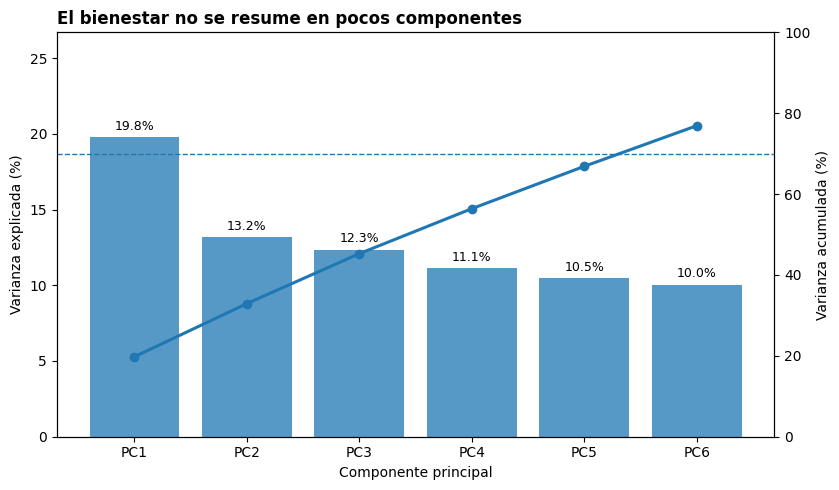

In [60]:
# ============================================================
# FIGURA PCA 1 — VARIANZA EXPLICADA Y ACUMULADA
# ============================================================

var_ind = 100 * pca_model.explained_variance_ratio_
var_acum = 100 * np.cumsum(
    pca_model.explained_variance_ratio_
)

componentes = np.arange(
    1,
    len(var_ind) + 1
)

fig, ax1 = plt.subplots(
    figsize=(8.5, 5.0)
)

bars = ax1.bar(
    componentes,
    var_ind,
    alpha=0.75
)

ax1.set_xlabel(
    "Componente principal"
)

ax1.set_ylabel(
    "Varianza explicada (%)"
)

ax1.set_xticks(
    componentes
)

ax1.set_xticklabels([
    f"PC{i}"
    for i in componentes
])

ax1.set_ylim(
    0,
    max(var_ind) * 1.35
)

for x, y in zip(
    componentes,
    var_ind
):
    ax1.text(
        x,
        y + 0.5,
        f"{y:.1f}%",
        ha="center",
        fontsize=9
    )

ax2 = ax1.twinx()

ax2.plot(
    componentes,
    var_acum,
    marker="o",
    linewidth=2.2
)

ax2.set_ylabel(
    "Varianza acumulada (%)"
)

ax2.set_ylim(
    0,
    100
)

ax2.axhline(
    70,
    linestyle="--",
    linewidth=1
)

ax1.set_title(
    "El bienestar no se resume en pocos componentes",
    loc="left",
    fontweight="bold"
)

fig.tight_layout()

plt.savefig(
    os.path.join(
        FIG_DIR,
        "02_pca_varianza_final.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

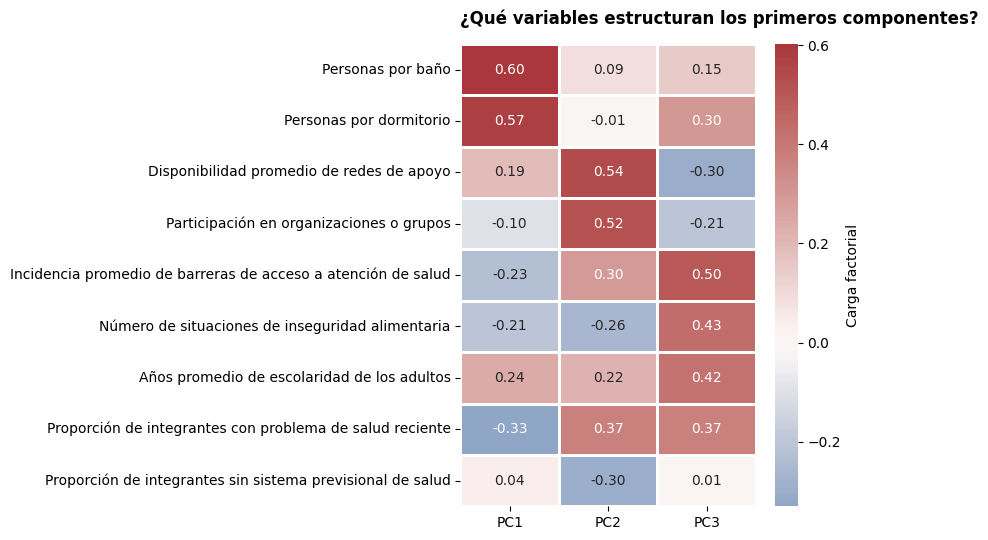

In [61]:
# ============================================================
# FIGURA PCA 2 — HEATMAP DE CARGAS
# ============================================================

import seaborn as sns

loadings_plot = loadings[
    ["PC1", "PC2", "PC3"]
].copy()

# Ordenar por importancia absoluta máxima
loadings_plot[
    "_orden"
] = (
    loadings_plot.abs()
    .max(axis=1)
)

loadings_plot = (
    loadings_plot
    .sort_values(
        "_orden",
        ascending=False
    )
    .drop(
        columns="_orden"
    )
)

fig, ax = plt.subplots(
    figsize=(8.5, 5.5)
)

sns.heatmap(
    loadings_plot,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    linewidths=1,
    linecolor="white",
    cbar_kws={
        "label":
            "Carga factorial"
    },
    ax=ax
)

ax.set_xlabel("")
ax.set_ylabel("")

ax.set_title(
    "¿Qué variables estructuran los primeros componentes?",
    loc="left",
    fontweight="bold",
    pad=14
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIG_DIR,
        "03_pca_heatmap_cargas.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

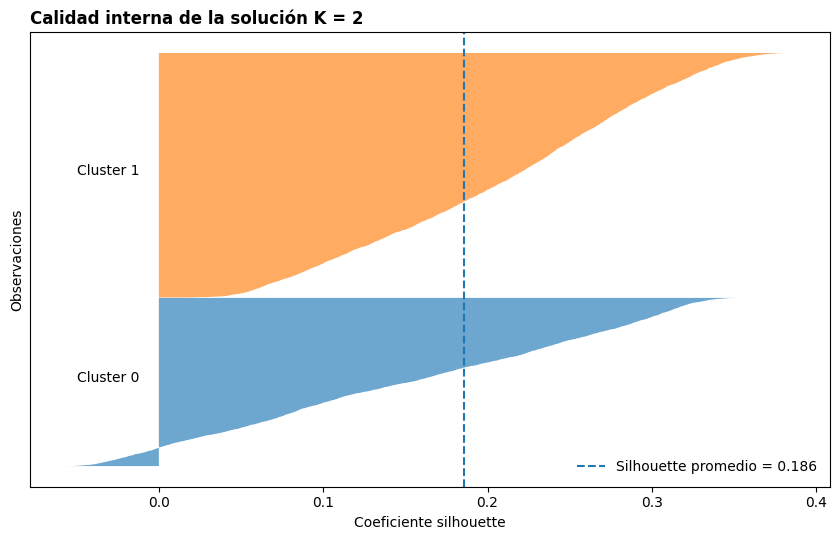

In [62]:
# ============================================================
# K-MEANS 1 — SILHOUETTE POR OBSERVACIÓN
# ============================================================

from sklearn.metrics import silhouette_samples

sil_values = silhouette_samples(
    X_cluster,
    pobres["cluster_kmeans"]
)

sil_avg = silhouette_score(
    X_cluster,
    pobres["cluster_kmeans"]
)

fig, ax = plt.subplots(
    figsize=(8.5, 5.5)
)

y_lower = 10

for cluster in sorted(
    pobres[
        "cluster_kmeans"
    ].unique()
):

    vals = sil_values[
        pobres[
            "cluster_kmeans"
        ].to_numpy()
        == cluster
    ]

    vals.sort()

    size_cluster = len(vals)

    y_upper = (
        y_lower
        + size_cluster
    )

    ax.fill_betweenx(
        np.arange(
            y_lower,
            y_upper
        ),
        0,
        vals,
        alpha=0.65
    )

    ax.text(
        -0.05,
        y_lower
        + 0.5 * size_cluster,
        f"Cluster {cluster}"
    )

    y_lower = (
        y_upper
        + 10
    )

ax.axvline(
    sil_avg,
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Silhouette promedio = "
        f"{sil_avg:.3f}"
    )
)

ax.set_xlabel(
    "Coeficiente silhouette"
)

ax.set_ylabel(
    "Observaciones"
)

ax.set_yticks([])

ax.set_title(
    "Calidad interna de la solución K = 2",
    loc="left",
    fontweight="bold"
)

ax.legend(
    frameon=False
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIG_DIR,
        "04_kmeans_silhouette_observaciones.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

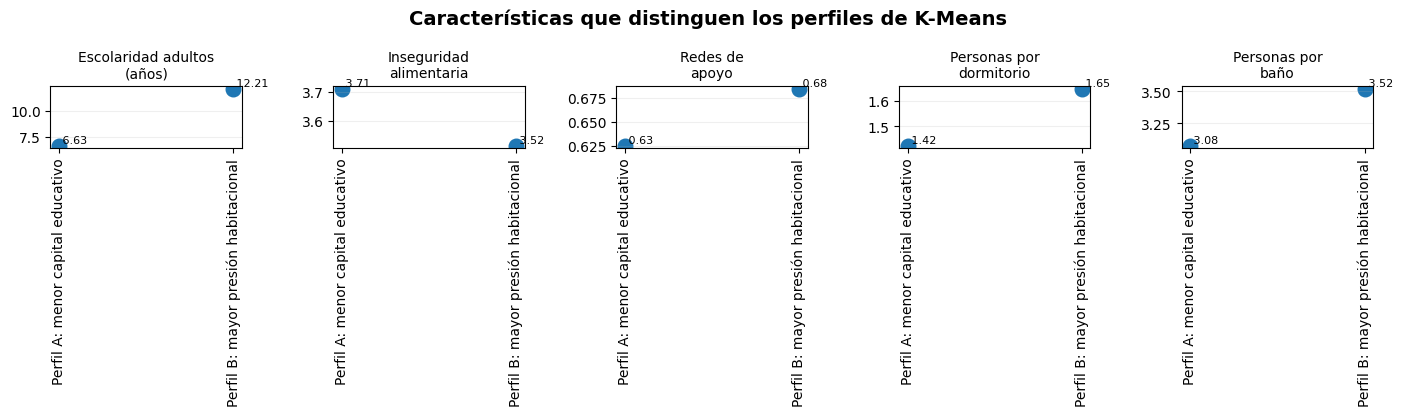

In [63]:
# ============================================================
# K-MEANS 2 — VARIABLES CLAVE POR PERFIL
# ============================================================

variables_clave = {
    "esc_media_adultos":
        "Escolaridad adultos\n(años)",

    "inseguridad_alimentaria_n":
        "Inseguridad\nalimentaria",

    "apoyo_score":
        "Redes de\napoyo",

    "personas_por_dormitorio":
        "Personas por\ndormitorio",

    "personas_por_bano":
        "Personas por\nbaño"
}


rows = []

for perfil, g in pobres.groupby(
    "perfil_kmeans"
):

    for var, nombre in variables_clave.items():

        rows.append({
            "Perfil":
                perfil,

            "Variable":
                nombre,

            "Media":
                weighted_mean(
                    g[var],
                    g["expr"]
                )
        })


perfil_long = pd.DataFrame(
    rows
)


fig, axes = plt.subplots(
    1,
    len(
        variables_clave
    ),
    figsize=(14, 4.2)
)


for ax, variable in zip(
    axes,
    variables_clave.values()
):

    datos = perfil_long[
        perfil_long[
            "Variable"
        ] == variable
    ]

    ax.scatter(
        datos["Perfil"],
        datos["Media"],
        s=110
    )

    for _, r in datos.iterrows():

        ax.text(
            r["Perfil"],
            r["Media"],
            f' {r["Media"]:.2f}',
            va="bottom",
            fontsize=8
        )

    ax.set_title(
        variable,
        fontsize=10
    )

    ax.set_xlabel("")

    ax.tick_params(
        axis="x",
        rotation=90
    )

    ax.grid(
        axis="y",
        alpha=0.2
    )


fig.suptitle(
    "Características que distinguen los perfiles de K-Means",
    fontweight="bold",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIG_DIR,
        "05_kmeans_variables_clave.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

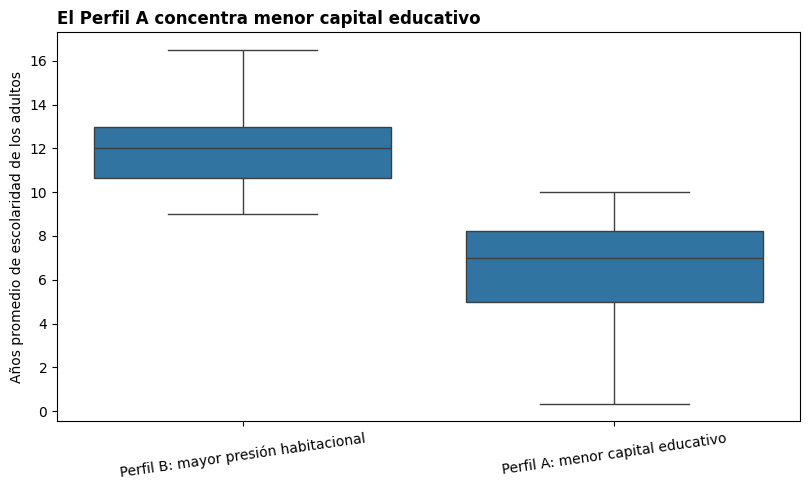

In [64]:
# ============================================================
# K-MEANS 3A — DISTRIBUCIÓN DE ESCOLARIDAD
# ============================================================

fig, ax = plt.subplots(
    figsize=(8.2, 5.0)
)

sns.boxplot(
    data=pobres,
    x="perfil_kmeans",
    y="esc_media_adultos",
    showfliers=False,
    ax=ax
)

ax.set_xlabel("")

ax.set_ylabel(
    "Años promedio de escolaridad de los adultos"
)

ax.set_title(
    "El Perfil A concentra menor capital educativo",
    loc="left",
    fontweight="bold"
)

ax.tick_params(
    axis="x",
    rotation=8
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIG_DIR,
        "06_kmeans_boxplot_educacion.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

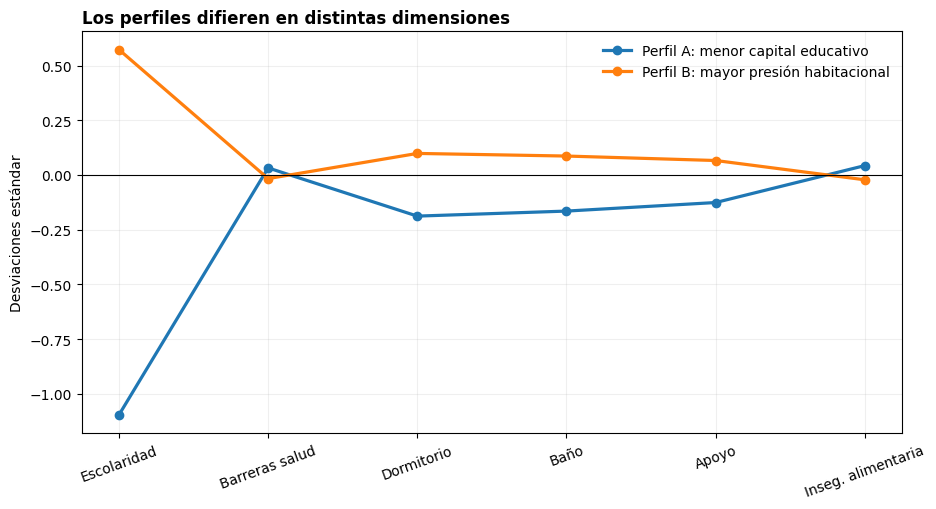

In [65]:
# ============================================================
# K-MEANS 4 — COORDENADAS PARALELAS DE LOS CENTROIDES
# ============================================================

perfil_vars = [
    "esc_media_adultos",
    "prop_barreras_acceso_salud",
    "personas_por_dormitorio",
    "personas_por_bano",
    "apoyo_score",
    "inseguridad_alimentaria_n"
]

labels_vars = [
    "Escolaridad",
    "Barreras salud",
    "Dormitorio",
    "Baño",
    "Apoyo",
    "Inseg. alimentaria"
]


temp = pobres[
    perfil_vars
    + [
        "perfil_kmeans",
        "expr"
    ]
].copy()


# Z-score ponderado
for var in perfil_vars:

    mu = weighted_mean(
        temp[var],
        temp["expr"]
    )

    sd = np.sqrt(
        np.average(
            (
                temp[var].fillna(mu)
                - mu
            )**2,
            weights=temp["expr"]
        )
    )

    temp[
        var + "_z"
    ] = (
        temp[var].fillna(mu)
        - mu
    ) / sd


centros = []


for perfil, g in temp.groupby(
    "perfil_kmeans"
):

    row = {
        "Perfil": perfil
    }

    for var in perfil_vars:

        row[var] = weighted_mean(
            g[
                var + "_z"
            ],
            g["expr"]
        )

    centros.append(
        row
    )


centros = pd.DataFrame(
    centros
)


fig, ax = plt.subplots(
    figsize=(9.5, 5.2)
)

x = np.arange(
    len(
        perfil_vars
    )
)


for _, r in centros.iterrows():

    ax.plot(
        x,
        [
            r[v]
            for v in perfil_vars
        ],
        marker="o",
        linewidth=2.3,
        label=r["Perfil"]
    )


ax.axhline(
    0,
    linewidth=0.8,
    color="black"
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    labels_vars,
    rotation=20
)

ax.set_ylabel(
    "Desviaciones estándar"
)

ax.set_title(
    "Los perfiles difieren en distintas dimensiones",
    loc="left",
    fontweight="bold"
)

ax.legend(
    frameon=False
)

ax.grid(
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIG_DIR,
        "08_kmeans_coordenadas_paralelas.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

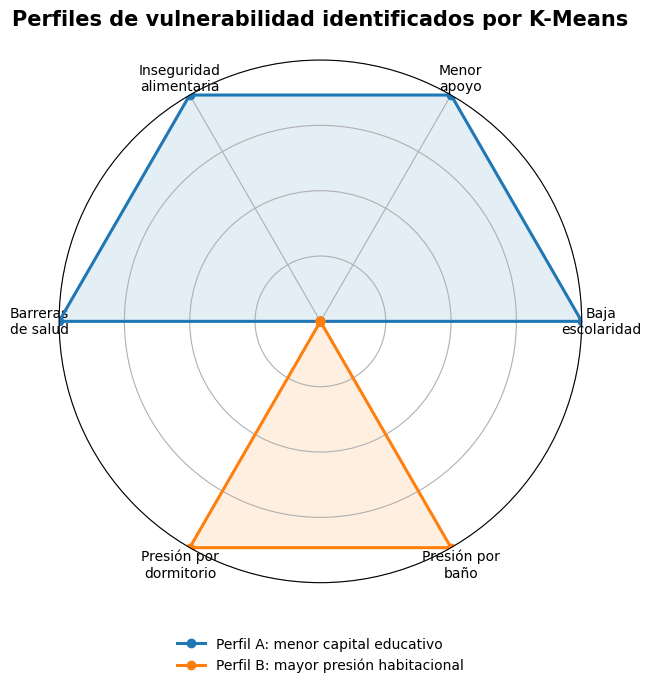

In [66]:
# ============================================================
# K-MEANS — RADAR DE PERFILES DE VULNERABILIDAD
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# VARIABLES DEL PERFIL
# +1: mayor valor = mayor vulnerabilidad
# -1: menor valor = mayor vulnerabilidad
# ------------------------------------------------------------

radar_vars = {
    "esc_media_adultos": (
        "Baja\nescolaridad",
        -1
    ),

    "apoyo_score": (
        "Menor\napoyo",
        -1
    ),

    "inseguridad_alimentaria_n": (
        "Inseguridad\nalimentaria",
        +1
    ),

    "prop_barreras_acceso_salud": (
        "Barreras\nde salud",
        +1
    ),

    "personas_por_dormitorio": (
        "Presión por\ndormitorio",
        +1
    ),

    "personas_por_bano": (
        "Presión por\nbaño",
        +1
    )
}


# ------------------------------------------------------------
# FUNCIONES PONDERADAS
# ------------------------------------------------------------

def wmean(x, w):

    x = pd.Series(x)
    w = pd.Series(w)

    valid = (
        x.notna()
        & w.notna()
        & np.isfinite(x)
        & np.isfinite(w)
        & (w > 0)
    )

    return np.average(
        x[valid],
        weights=w[valid]
    )


def wstd(x, w):

    x = pd.Series(x)
    w = pd.Series(w)

    valid = (
        x.notna()
        & w.notna()
        & np.isfinite(x)
        & np.isfinite(w)
        & (w > 0)
    )

    xv = x[valid].to_numpy()
    wv = w[valid].to_numpy()

    mu = np.average(
        xv,
        weights=wv
    )

    return np.sqrt(
        np.average(
            (xv - mu)**2,
            weights=wv
        )
    )


# ------------------------------------------------------------
# ESTANDARIZAR
# ------------------------------------------------------------

radar_rows = []

for var, (label, direction) in radar_vars.items():

    mu = wmean(
        pobres[var],
        pobres["expr"]
    )

    sd = wstd(
        pobres[var],
        pobres["expr"]
    )

    z_col = f"__radar_{var}"

    pobres[z_col] = (
        direction
        * (
            pobres[var].fillna(mu)
            - mu
        )
        / sd
    )


    for perfil, g in pobres.groupby(
        "perfil_kmeans"
    ):

        radar_rows.append({
            "Perfil": perfil,
            "Indicador": label,
            "Score": wmean(
                g[z_col],
                g["expr"]
            )
        })


radar_df = pd.DataFrame(
    radar_rows
)


# ------------------------------------------------------------
# REESCALAR SOLO PARA VISUALIZACIÓN DEL RADAR
# 0 = menor vulnerabilidad relativa
# 1 = mayor vulnerabilidad relativa
# ------------------------------------------------------------

pivot = radar_df.pivot(
    index="Perfil",
    columns="Indicador",
    values="Score"
)

labels = [
    x[0]
    for x in radar_vars.values()
]

pivot = pivot[
    labels
]


# escala común por indicador
radar_scaled = pivot.copy()

for c in radar_scaled.columns:

    mn = radar_scaled[c].min()
    mx = radar_scaled[c].max()

    if mx == mn:
        radar_scaled[c] = 0.5
    else:
        radar_scaled[c] = (
            radar_scaled[c]
            - mn
        ) / (
            mx - mn
        )


# ------------------------------------------------------------
# RADAR
# ------------------------------------------------------------

N = len(labels)

angles = np.linspace(
    0,
    2 * np.pi,
    N,
    endpoint=False
).tolist()

angles += angles[:1]


fig, ax = plt.subplots(
    figsize=(8, 7),
    subplot_kw=dict(
        polar=True
    )
)


for perfil in radar_scaled.index:

    values = (
        radar_scaled.loc[
            perfil
        ]
        .tolist()
    )

    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2.2,
        marker="o",
        label=perfil
    )

    ax.fill(
        angles,
        values,
        alpha=0.12
    )


ax.set_xticks(
    angles[:-1]
)

ax.set_xticklabels(
    labels,
    fontsize=10
)

ax.set_ylim(
    0,
    1
)

ax.set_yticks([
    0.25,
    0.50,
    0.75,
    1.00
])

ax.set_yticklabels([
    "",
    "",
    "",
    ""
])

ax.set_title(
    "Perfiles de vulnerabilidad identificados por K-Means",
    pad=25,
    fontsize=15,
    fontweight="bold"
)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.08),
    frameon=False
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIG_DIR,
        "11_kmeans_radar_perfiles.png"
    ),
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.1
)

plt.show()

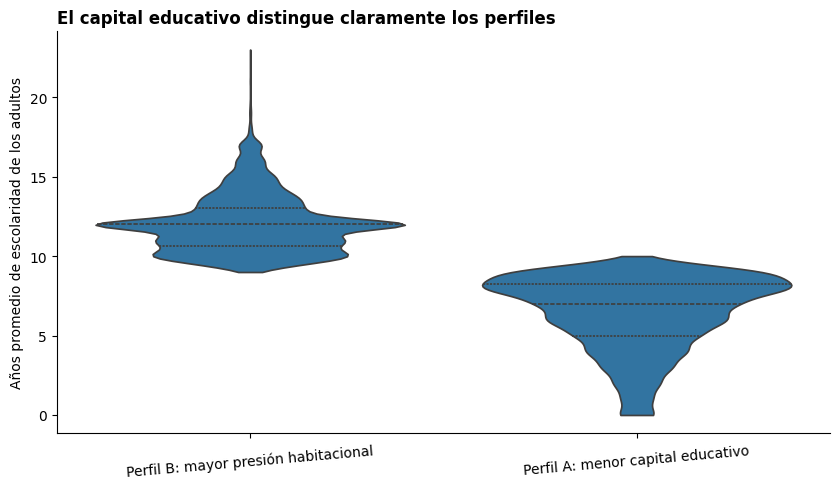

In [67]:
# ============================================================
# K-MEANS — VIOLIN PLOT
# EDUCACIÓN Y PRESIÓN HABITACIONAL
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# EDUCACIÓN
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8.5, 5)
)

sns.violinplot(
    data=pobres,
    x="perfil_kmeans",
    y="esc_media_adultos",
    inner="quartile",
    cut=0,
    density_norm="width",
    ax=ax
)

ax.set_xlabel("")

ax.set_ylabel(
    "Años promedio de escolaridad de los adultos"
)

ax.set_title(
    "El capital educativo distingue claramente los perfiles",
    loc="left",
    fontweight="bold"
)

ax.tick_params(
    axis="x",
    rotation=5
)

sns.despine()

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIG_DIR,
        "12_kmeans_violin_educacion.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

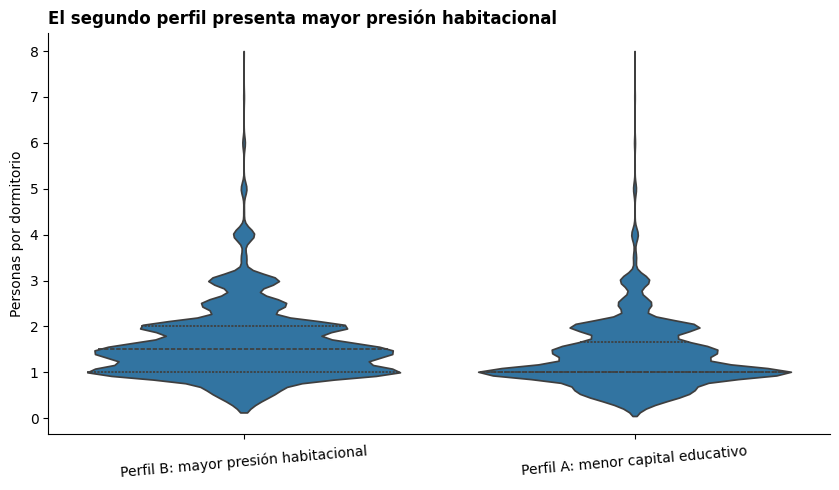

In [68]:
# ============================================================
# K-MEANS — VIOLIN PLOT DE PRESIÓN HABITACIONAL
# ============================================================

fig, ax = plt.subplots(
    figsize=(8.5, 5)
)

sns.violinplot(
    data=pobres,
    x="perfil_kmeans",
    y="personas_por_dormitorio",
    inner="quartile",
    cut=0,
    density_norm="width",
    ax=ax
)

ax.set_xlabel("")

ax.set_ylabel(
    "Personas por dormitorio"
)

ax.set_title(
    "El segundo perfil presenta mayor presión habitacional",
    loc="left",
    fontweight="bold"
)

ax.tick_params(
    axis="x",
    rotation=5
)

sns.despine()

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIG_DIR,
        "13_kmeans_violin_vivienda.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ORDEN RECOMENDADO PARA INFORME Y PRESENTACIÓN

## 1. Motivación descriptiva
Usar:

- `01_solapamiento_pobreza_personas.png`
- tasas de pobreza por ingresos, multidimensional e intersección.

**Mensaje:** incidencias agregadas similares no implican que se trate de los mismos hogares/personas.

---

## 2. PCA — primera herramienta

Usar:

- `02_pca_scree.png`
- `03_pca_contribucion_pc1_pc2.png`

**Mensaje:** el PCA resume la estructura de asociación entre variables de bienestar y permite identificar qué variables estructuran los principales ejes de heterogeneidad.

---

## 3. K-Means — segunda herramienta y resultado principal

Usar:

- `04_kmeans_silhouette.png`
- `05_kmeans_calinski_harabasz.png`
- `06_pca_clusters_pc1_pc2.png`

**Mensaje:** K-Means identifica dos perfiles sustantivos dentro de los hogares pobres multidimensionales. La proyección PCA permite visualizar la separación en dos dimensiones.

---

## 4. Caracterización de perfiles

Usar:

- `07_perfil_clusters_heatmap.png`
- `09_perfil_clusters.csv`

**Mensaje:** los grupos no constituyen simplemente una escala de “más” y “menos” pobreza; presentan configuraciones diferentes de vulnerabilidad.

---

## 5. Fraiman como extensión complementaria

Usar:

- `08_fraiman_variable_ecdf.png`, si se genera;
- `09_fraiman_reasignacion.png`;
- `10_fraiman_blinding.csv`.

**Mensaje:** el blinding evalúa qué subconjunto mínimo de variables originales reproduce la partición de K-Means.

---

## 6. Validación externa

Usar:

- `10_validacion_pobreza_ingresos.png`.

**Mensaje:** se contrasta la clasificación no supervisada con pobreza por ingresos sin utilizarla para formar los clusters.

---

## Frase metodológica para la defensa

> “La exposición utiliza dos herramientas principales vistas en clase: PCA para explorar y representar la estructura multidimensional, y K-Means para identificar perfiles dentro de los hogares pobres multidimensionales. Posteriormente utilizamos una aproximación al blinding de Fraiman como procedimiento complementario de selección de variables, siguiendo la lógica del artículo de referencia.”

## Precaución

No presentar PCA como algoritmo que determina los clusters ni Fraiman como un tercer modelo predictivo. PCA cumple un rol exploratorio, K-Means genera la partición y Fraiman evalúa qué variables originales son suficientes para reproducirla.